In [1]:
from itertools import product
import psutil
from functools import partial
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
from qiskit_addon_sqd.counts import counts_to_arrays, bit_array_to_arrays
from tqdm.notebook import tqdm
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import os
import matplotlib.pyplot as plt
from glob import glob
import seaborn as sns 
from tqdm.notebook import tqdm
from matplotlib import font_manager
import scipy.stats as stats
from shutil import move
font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})




# GMJ plot ideas
- Deviation from standard LUCJ (CCSD t1/t2 amps)
- Deviation of all initializations from HCI? (Maybe useless for this case; see point 1)
- Something to highlight SQDs "robustness" regarding initialization
    - Deviation from standard LUCJ (CCSD t1/t2 amps) but use barplot and explicitly highlight the GDB cases larger than 20 orbitals (see Kevin Sung where they mention initializations beyond 30 orbitals)
    - Boxplot deviations where the y-axis is deviations, x-axis is the basis set and the hue is the injection type
- Number of correct Hamming strings (ON vectors) *before* SQD

In [2]:
UofT_palette = [ "#1E3765",
                 "#007FA3", 
                 "#6D247A", 
                 "#DC4633",
                 "#6FC7EA",
                 "#00A189",
                 "#AB1368",
                 "#0D534D",
                 "#F1C500",
                 "#8DBF2E"
               ]

palette = sns.color_palette(UofT_palette)

In [3]:
energyDF=pd.read_csv("../../../classical/energies.csv",index_col=0)
moldf = pd.read_csv('molecules.csv')
activespacedf = pd.read_csv("active_spaces.csv")

In [4]:
activespacedf

,molecule,n_frozen,num_orbitals,n_electrons
0,water,0,7,10
1,ammonia,0,8,10
2,methane,0,9,10
3,formaldehyde,0,12,16
4,ethylene,0,14,16
5,ethane,0,16,18
6,methanol,0,14,18
7,GDB04_53,0,26,30
8,GDB04_49,0,26,30
9,GDB04_33,0,26,32


In [5]:
import re

def process_list(data_list):
    """
    Processes a list of strings to perform the following operations:
    1.  Strips trailing newline characters.
    2.  Parses the 'LUCJ' string into three separate elements.
    3.  Converts the final element from a string to a float.
    """
    processed_list = []
    for item in data_list:
        item = item.strip()

        if "LUCJ" in item:
            # Use a regular expression to extract the components
            match = re.search(r'(LUCJ)\(L=(.*?)\)/(.*)', item)
            if match:
                processed_list.extend(match.groups())
            else:
                processed_list.append(item)
        else:
            processed_list.append(item)
    
    # Convert the last element to a float
    # We use a try-except block in case the last element is not a number
    try:
        processed_list[-1] = float(processed_list[-1])
    except (ValueError, IndexError):
        pass # The last element is not a float, so we ignore it

    return processed_list

In [6]:
postprocessed = []
new = []

for i in tqdm(glob("./energies/*txt"), desc='Running'):
    if 'StateVector' not in i:
        with open(i, 'r') as f:
            lines = f.readlines()
        
        # Filter out empty lines and non-energy metadata lines like 'Subspace Dimension'
        lines = [
            line for line in lines 
            if line.strip() and not line.strip().startswith("Subspace Dimension")
        ]
        
        processed = process_list(lines)
        
        # Clean energy string if needed
        if isinstance(processed[-1], str):
            # Strip 'Energy:', brackets, and whitespace
            clean_energy = (
                processed[-1]
                .replace("Energy:", "")
                .strip(" []\t\n")
            )
            processed[-1] = float(clean_energy)
            
        # Build dataframe with clean types
        cols = ["Basis Set", "Molecule", "Method", "L", "Injected", "Energy"]
        moldict = pd.DataFrame([dict(zip(cols, processed))]).astype({"L": int, "Energy": float})
        
        postprocessed.append(moldict)
        new.append(i)

Running:   0%|          | 0/1260 [00:00<?, ?it/s]

In [7]:
LUCJDF=pd.concat(postprocessed).reset_index().drop(columns=['index']).astype({"L":int,"Energy":float})
LUCJDF['Method'] =[f"LUCJ(L={i})" for i in LUCJDF['L']]

In [8]:
# LUCJDF[LUCJDF['Energy']<-1e3].to_excel("repostprocess.xlsx")

In [9]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

LUCJDF['n_atoms'] = LUCJDF['Molecule'].map(n_atoms_dict)

In [10]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueBasis = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']
uniqueMol = sorted(LUCJDF['Molecule'].unique(), key=lambda user: n_atoms_dict.get(user, 0))
# uniqueInj = LUCJDF['Injected'].unique()
uniqueInj = ['zeroes', 'random', 'MP2', 'ML', 'ML_exact', 'CCSD']
uniqueLayers = np.sort(LUCJDF['L'].unique())
uniqueMethods = np.hstack([LUCJDF['Method'].sort_values().unique(),energyDF['Method'].unique()])

In [11]:
for basis, layer, mol in product(uniqueBasis, uniqueLayers, uniqueMol):
    mask = (
        (LUCJDF['Basis Set'] == basis) &
        (LUCJDF['L'] == layer) &
        (LUCJDF['Molecule'] == mol)
    )
    
    # If no data exists for this mask in LUCJDF, skip to next iteration
    if not mask.any():
        continue

    # Determine standard or mapping name for energyDF lookup
    lookup_mol = mol
    sci_sub = energyDF[(energyDF['Name'] == lookup_mol) & (energyDF['Basis Set'] == basis) & (energyDF['Method'] == 'SCI')]
    
    # If standard lookup fails, try converting via moldf
    if sci_sub.empty and 'moldf' in globals():
        mapped = moldf.loc[moldf['molecule'] == mol, 'xyz'] if 'xyz' in moldf.columns else moldf.loc[moldf['molecule'] == mol, 'mol_filename']
        if not mapped.empty:
            lookup_mol = mapped.values[0].replace('.xyz', '')

    # Helper function to safely extract scalar energy or np.nan if absent
    def get_energy(method_name):
        sub = energyDF[(energyDF['Name'] == lookup_mol) & 
                       (energyDF['Basis Set'] == basis) & 
                       (energyDF['Method'] == method_name)]
        return sub['Energy'].values[0] if not sub.empty else np.nan

    sci_energy = get_energy('SCI')
    hf_energy = get_energy('HF')
    casci_energy = get_energy('CASCI')
    dmrg_energy = get_energy('DMRG-CASCI')

    # Assign values safely
    if not np.isnan(sci_energy):
        LUCJDF.loc[mask, 'Deviation'] = (LUCJDF.loc[mask, "Energy"] - dmrg_energy) * 1e3
    LUCJDF.loc[mask, 'Energy (HCI)'] = sci_energy

    LUCJDF.loc[mask, 'Energy (HF)'] = hf_energy
    LUCJDF.loc[mask, 'Energy (CASCI)'] = casci_energy
    LUCJDF.loc[mask, 'Energy (DMRG-CASCI)'] = dmrg_energy


In [12]:
flatteneddev = []


In [13]:
LUCJDF

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI),Energy (DMRG-CASCI)
0,cc-pVDZ,but-1-yne,LUCJ(L=5),5,MP2,-154.911460,10,95.209644,-155.000448,-154.911388,NaN,-155.006670
1,STO-3G,ethylene,LUCJ(L=3),3,random,-77.233270,6,1.766459,-77.233917,-77.071233,-77.235036,-77.235036
2,cc-pVDZ,but-1-yne,LUCJ(L=1),1,MP2,-154.940648,10,66.022134,-155.000448,-154.911388,NaN,-155.006670
3,aug-cc-pVDZ,ethane,LUCJ(L=2),2,ML,-79.237075,8,0.075056,-79.237128,-79.236978,-79.237150,-79.237150
4,STO-3G,prop-2-en-1-ol,LUCJ(L=5),5,CCSD,-189.487318,10,262.077941,-189.727016,-189.480427,NaN,-189.749396
...,...,...,...,...,...,...,...,...,...,...,...,...
1075,STO-3G,water,LUCJ(L=2),2,ML,-75.009479,3,0.000136,-75.009478,-74.960552,-75.009479,-75.009479
1076,aug-cc-pVDZ,ammonia,LUCJ(L=4),4,zeroes,-56.205309,4,-301.367509,-56.205307,-56.205223,-56.205309,-55.903941
1077,cc-pVDZ,formaldehyde,LUCJ(L=2),2,ML,-113.914290,4,0.000196,-113.914187,-113.872781,-113.914290,-113.914290
1078,aug-cc-pVDZ,ethane,LUCJ(L=5),5,random,-79.237060,8,0.089616,-79.237128,-79.236978,-79.237150,-79.237150


In [14]:
findDevCCSD = LUCJDF[['Basis Set','Molecule','L','Injected','Energy','n_atoms']].copy()

In [15]:
# uniqueBasis = LUCJDF['Basis Set'].unique()
for basis, mol, layer in product(uniqueBasis,uniqueMol,uniqueLayers):
    mask = (findDevCCSD['Basis Set']==basis)&(findDevCCSD['Molecule']==mol)&(findDevCCSD['L']==layer)
    # foundccsd = findDevCCSD.loc[mask]
    findDevCCSD.loc[mask,'Deviation'] = (findDevCCSD.loc[mask&(findDevCCSD['Injected'].isin(uniqueInj)),'Energy'] - findDevCCSD.loc[mask&(findDevCCSD['Injected']=='CCSD'),'Energy'].values) * 1e3
    # print(devfound)
# , 'CCSD']

In [16]:
findDevCCSD.loc[(findDevCCSD['Basis Set']=='STO-3G')&(findDevCCSD['Molecule']=='ammonia')]

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
93,STO-3G,ammonia,1,CCSD,-55.519929,4,0.00000
99,STO-3G,ammonia,5,zeroes,-55.519927,4,0.00256
101,STO-3G,ammonia,2,ML_exact,-55.519929,4,0.00000
152,STO-3G,ammonia,5,random,-55.519929,4,0.00000
195,STO-3G,ammonia,3,random,-55.519929,4,0.00000
277,STO-3G,ammonia,5,ML_exact,-55.519929,4,0.00000
306,STO-3G,ammonia,1,zeroes,-55.519928,4,0.00133
310,STO-3G,ammonia,1,MP2,-55.519929,4,0.00000
338,STO-3G,ammonia,3,ML_exact,-55.519929,4,0.00000
361,STO-3G,ammonia,5,MP2,-55.519929,4,0.00000


In [17]:
findDevCCSD

,Basis Set,Molecule,L,Injected,Energy,n_atoms,Deviation
0,cc-pVDZ,but-1-yne,5,MP2,-154.911460,10,0.46773
1,STO-3G,ethylene,3,random,-77.233270,6,1.07017
2,cc-pVDZ,but-1-yne,1,MP2,-154.940648,10,-22.51487
3,aug-cc-pVDZ,ethane,2,ML,-79.237075,8,-0.01591
4,STO-3G,prop-2-en-1-ol,5,CCSD,-189.487318,10,0.00000
...,...,...,...,...,...,...,...
1075,STO-3G,water,2,ML,-75.009479,3,0.00000
1076,aug-cc-pVDZ,ammonia,4,zeroes,-56.205309,4,0.00001
1077,cc-pVDZ,formaldehyde,2,ML,-113.914290,4,0.00000
1078,aug-cc-pVDZ,ethane,5,random,-79.237060,8,-0.00885


/tmp/ipykernel_20688/4253153649.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(


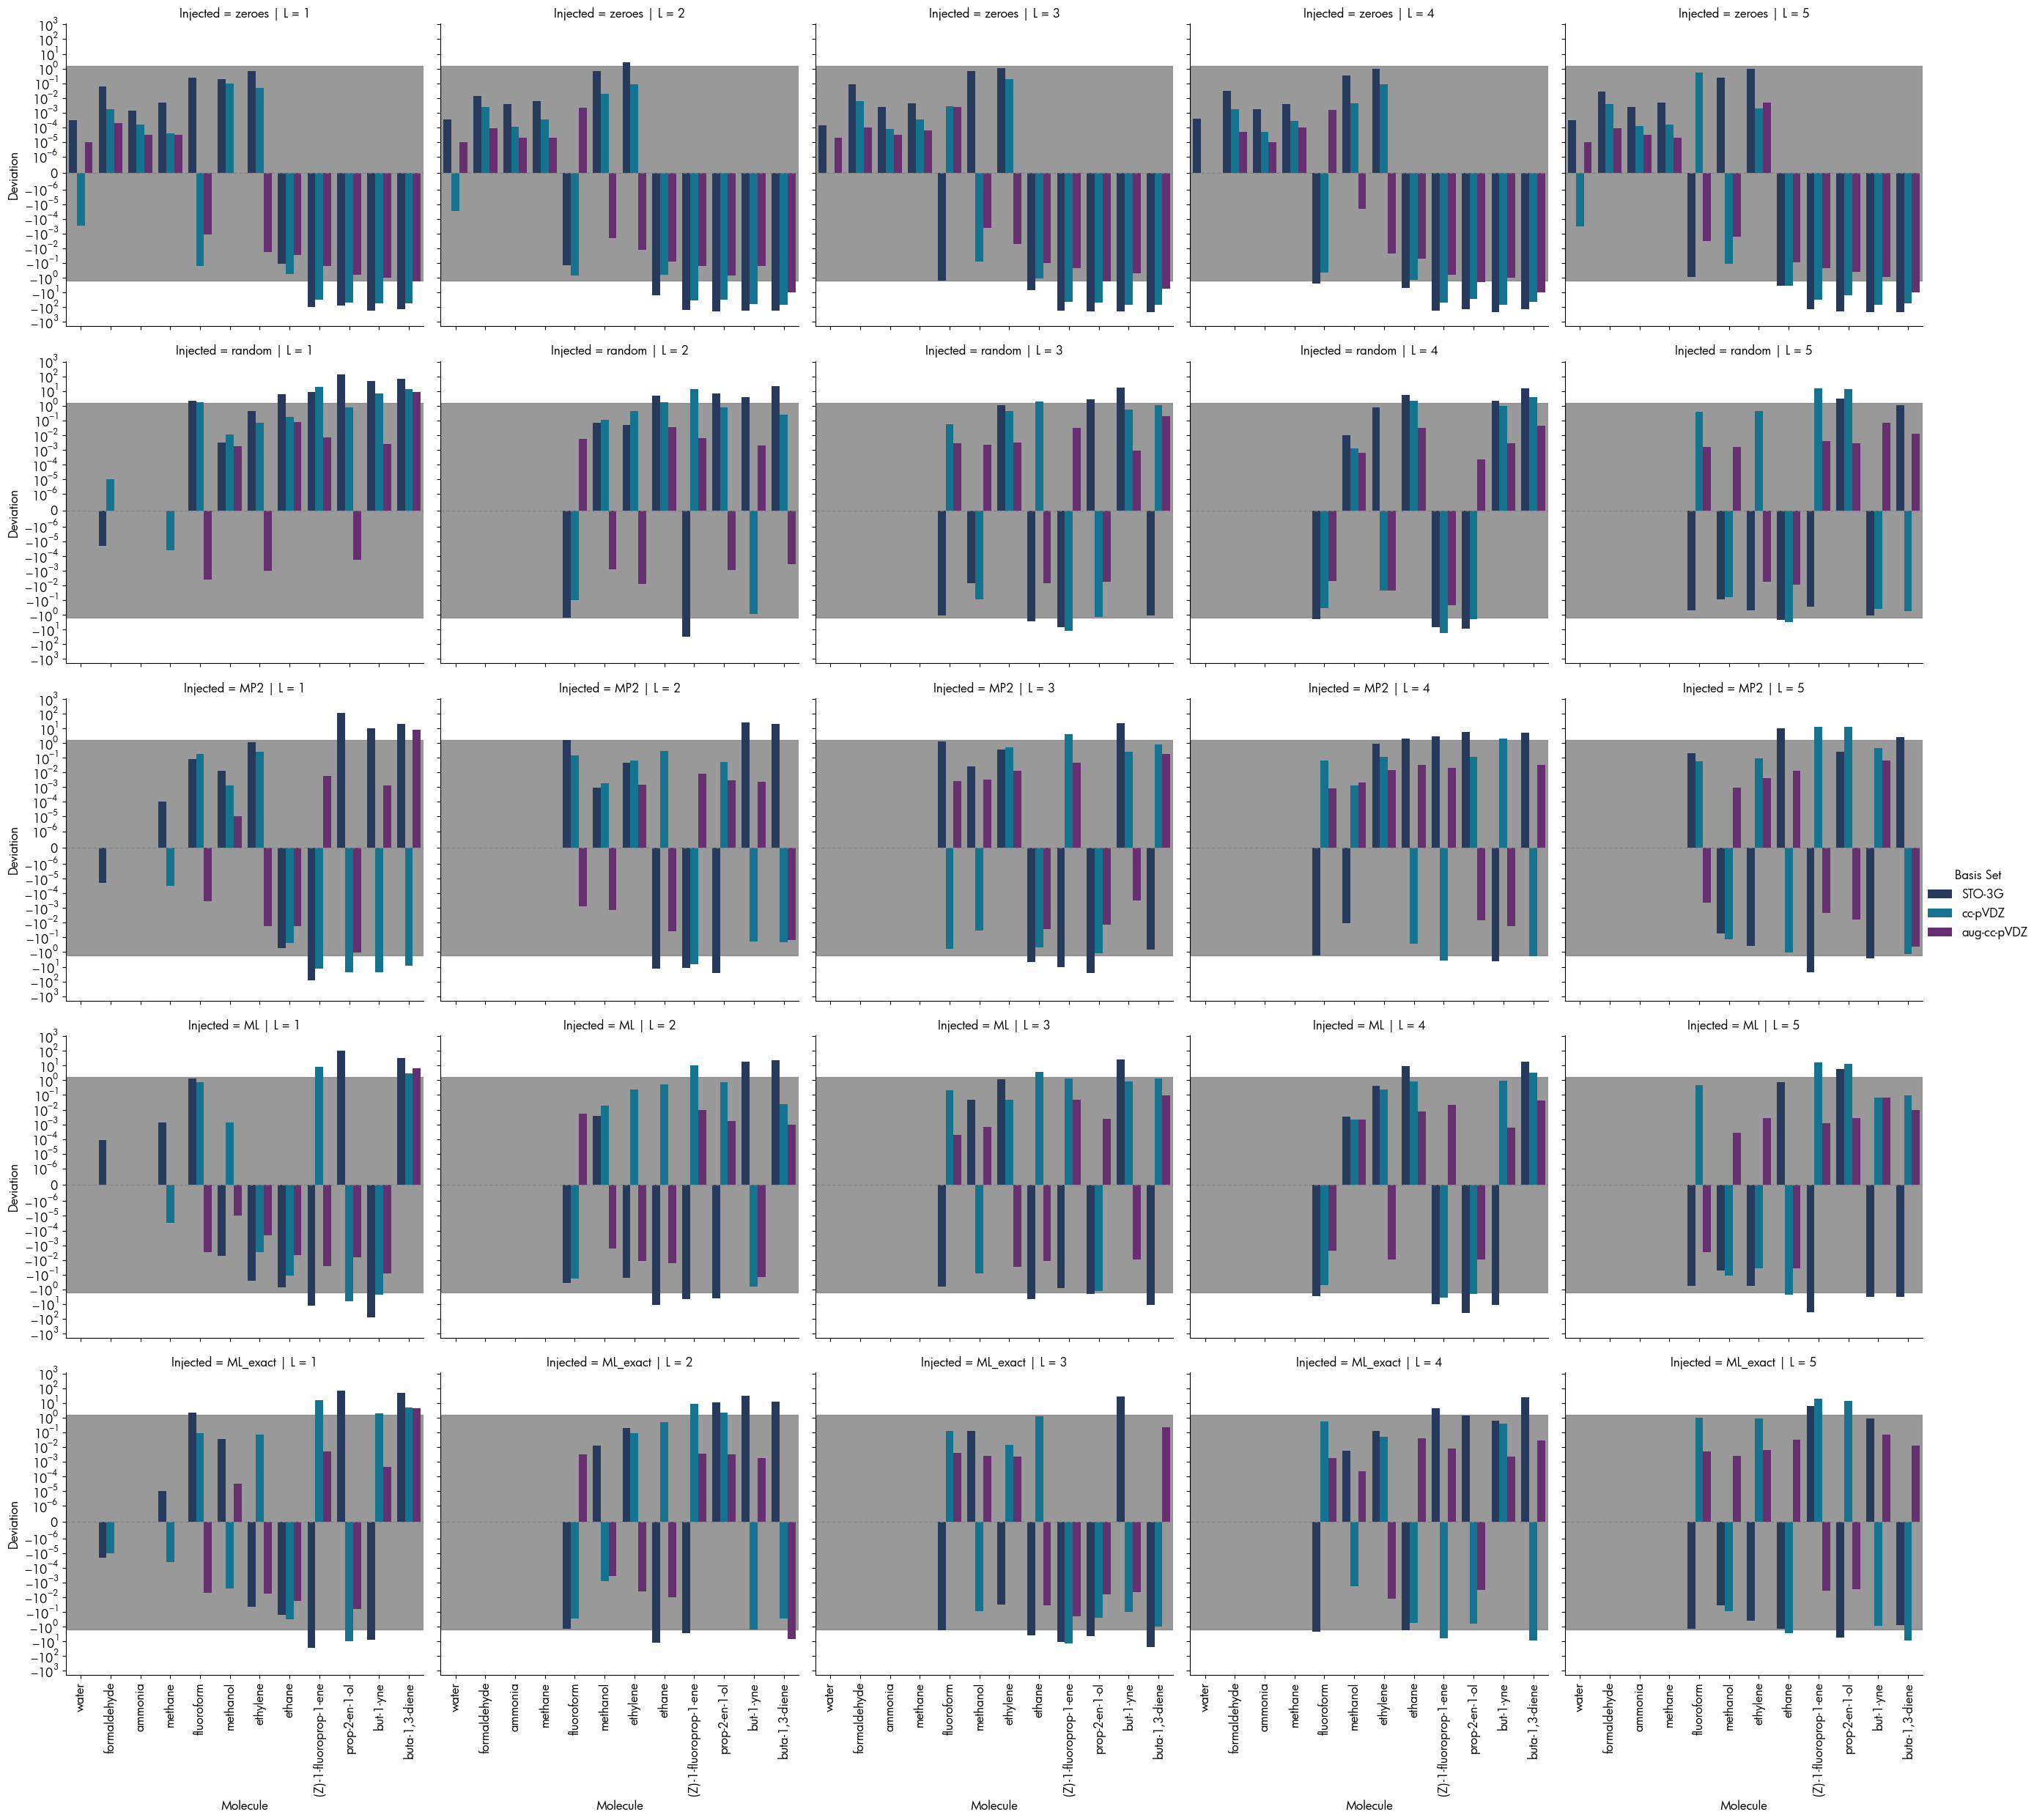

In [18]:


g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    hue='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    col='L',
    kind='bar',
    hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    row_order=['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],
    palette=palette
)

for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
# plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')

In [19]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis)
    print("min",findDevCCSD.loc[devfind.idxmin(),'Molecule'],f"{devfind.min():.2e}")
    print("max",findDevCCSD.loc[devfind.idxmax(),'Molecule'],f"{devfind.max():.2e}")
    print(devfind.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
    print(inj,basis,devfind[devfind.abs()>=1.6].shape[0])
    print()

zeroes STO-3G
min but-1-yne -2.31e+02
max ethylene 2.65e+00
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
zeroes STO-3G 27

zeroes cc-pVDZ
min but-1-yne -7.39e+01
max fluoroform 5.22e-01
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
zeroes cc-pVDZ 21

zeroes aug-cc-pVDZ
min buta-1,3-diene -1.03e+01
max ethylene 4.81e-03
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
zeroes aug-cc-pVDZ 7

random STO-3G
min (Z)-1-fluoroprop-1-ene -2.89e+01
max prop-2-en-1-ol 1.32e+02
mean     4.81e+00
min     -2.89e+01
max      1.32e+02
std      2.06e+01
Name: Deviation, dtype: object
random STO-3G 24

random cc-pVDZ
min (Z)-1-fluoroprop-1-ene -1.76e+01
max (Z)-1-fluoroprop-1-ene 1.93e+01
mean     1.06e+00
min     -1.76e+01
max      1.93e+01
std      5.39e+00
Name: Deviation, dtype: object
random cc-pVDZ 15

random aug-cc-pVDZ
min (Z)-1-

In [20]:
layer_inj_dev = []
for inj, layers in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],sorted(uniqueLayers)):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['L'] == layers),'Deviation']
    layer_inj_dev.append((inj,layers,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    print(inj,layers,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes 1 75.0
zeroes 2 69.44444444444444
zeroes 3 66.66666666666666
zeroes 4 66.66666666666666
zeroes 5 69.44444444444444
random 1 69.44444444444444
random 2 77.77777777777779
random 3 83.33333333333334
random 4 72.22222222222221
random 5 86.11111111111111
MP2 1 75.0
MP2 2 80.55555555555556
MP2 3 86.11111111111111
MP2 4 75.0
MP2 5 83.33333333333334
ML 1 75.0
ML 2 83.33333333333334
ML 3 86.11111111111111
ML 4 75.0
ML 5 80.55555555555556
ML_exact 1 72.22222222222221
ML_exact 2 77.77777777777779
ML_exact 3 80.55555555555556
ML_exact 4 83.33333333333334
ML_exact 5 83.33333333333334


In [21]:
mol_dev = []
for mol in uniqueMol:
    devfind = findDevCCSD.loc[(findDevCCSD['Molecule'] == mol),'Deviation']
    mol_dev.append((mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2))
    # print()

moldevdf = pd.DataFrame(mol_dev).sort_values(by=[1])
moldevdf['n_atoms'] = moldevdf[0].map(n_atoms_dict)    
# moldevdf[[0,1]].to_clipboard()

In [22]:
for inj, mol in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueMol):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Molecule'] == mol),'Deviation']
    print(inj,mol,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes water 100.0
zeroes formaldehyde 100.0
zeroes ammonia 100.0
zeroes methane 100.0
zeroes fluoroform 86.66666666666667
zeroes ethylene 93.33333333333333
zeroes methanol 100.0
zeroes ethane 66.66666666666666
zeroes (Z)-1-fluoroprop-1-ene 33.33333333333333
zeroes but-1-yne 33.33333333333333
zeroes prop-2-en-1-ol 20.0
zeroes buta-1,3-diene 0.0
random water 100.0
random formaldehyde 100.0
random ammonia 100.0
random methane 100.0
random fluoroform 73.33333333333333
random ethylene 100.0
random methanol 100.0
random ethane 40.0
random (Z)-1-fluoroprop-1-ene 40.0
random but-1-yne 66.66666666666666
random prop-2-en-1-ol 53.333333333333336
random buta-1,3-diene 60.0
MP2 water 100.0
MP2 formaldehyde 100.0
MP2 ammonia 100.0
MP2 methane 100.0
MP2 fluoroform 86.66666666666667
MP2 ethylene 100.0
MP2 methanol 100.0
MP2 ethane 73.33333333333333
MP2 (Z)-1-fluoroprop-1-ene 33.33333333333333
MP2 but-1-yne 53.333333333333336
MP2 prop-2-en-1-ol 60.0
MP2 buta-1,3-diene 53.333333333333336
ML water 100.0

In [23]:
for inj, basis in product(['zeroes', 'random', 'MP2', 'ML', 'ML_exact'],uniqueBasis):
    devfind = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set'] == basis),'Deviation']
    print(inj,basis,(devfind[devfind.abs()<=1.6].shape[0]/devfind.shape[0])*1e2)
    # print()

zeroes STO-3G 55.00000000000001
zeroes cc-pVDZ 65.0
zeroes aug-cc-pVDZ 88.33333333333333
random STO-3G 60.0
random cc-pVDZ 75.0
random aug-cc-pVDZ 98.33333333333333
MP2 STO-3G 60.0
MP2 cc-pVDZ 81.66666666666667
MP2 aug-cc-pVDZ 98.33333333333333
ML STO-3G 61.66666666666667
ML cc-pVDZ 80.0
ML aug-cc-pVDZ 98.33333333333333
ML_exact STO-3G 63.33333333333333
ML_exact cc-pVDZ 78.33333333333333
ML_exact aug-cc-pVDZ 96.66666666666667


/tmp/ipykernel_20688/1039327296.py:2: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(


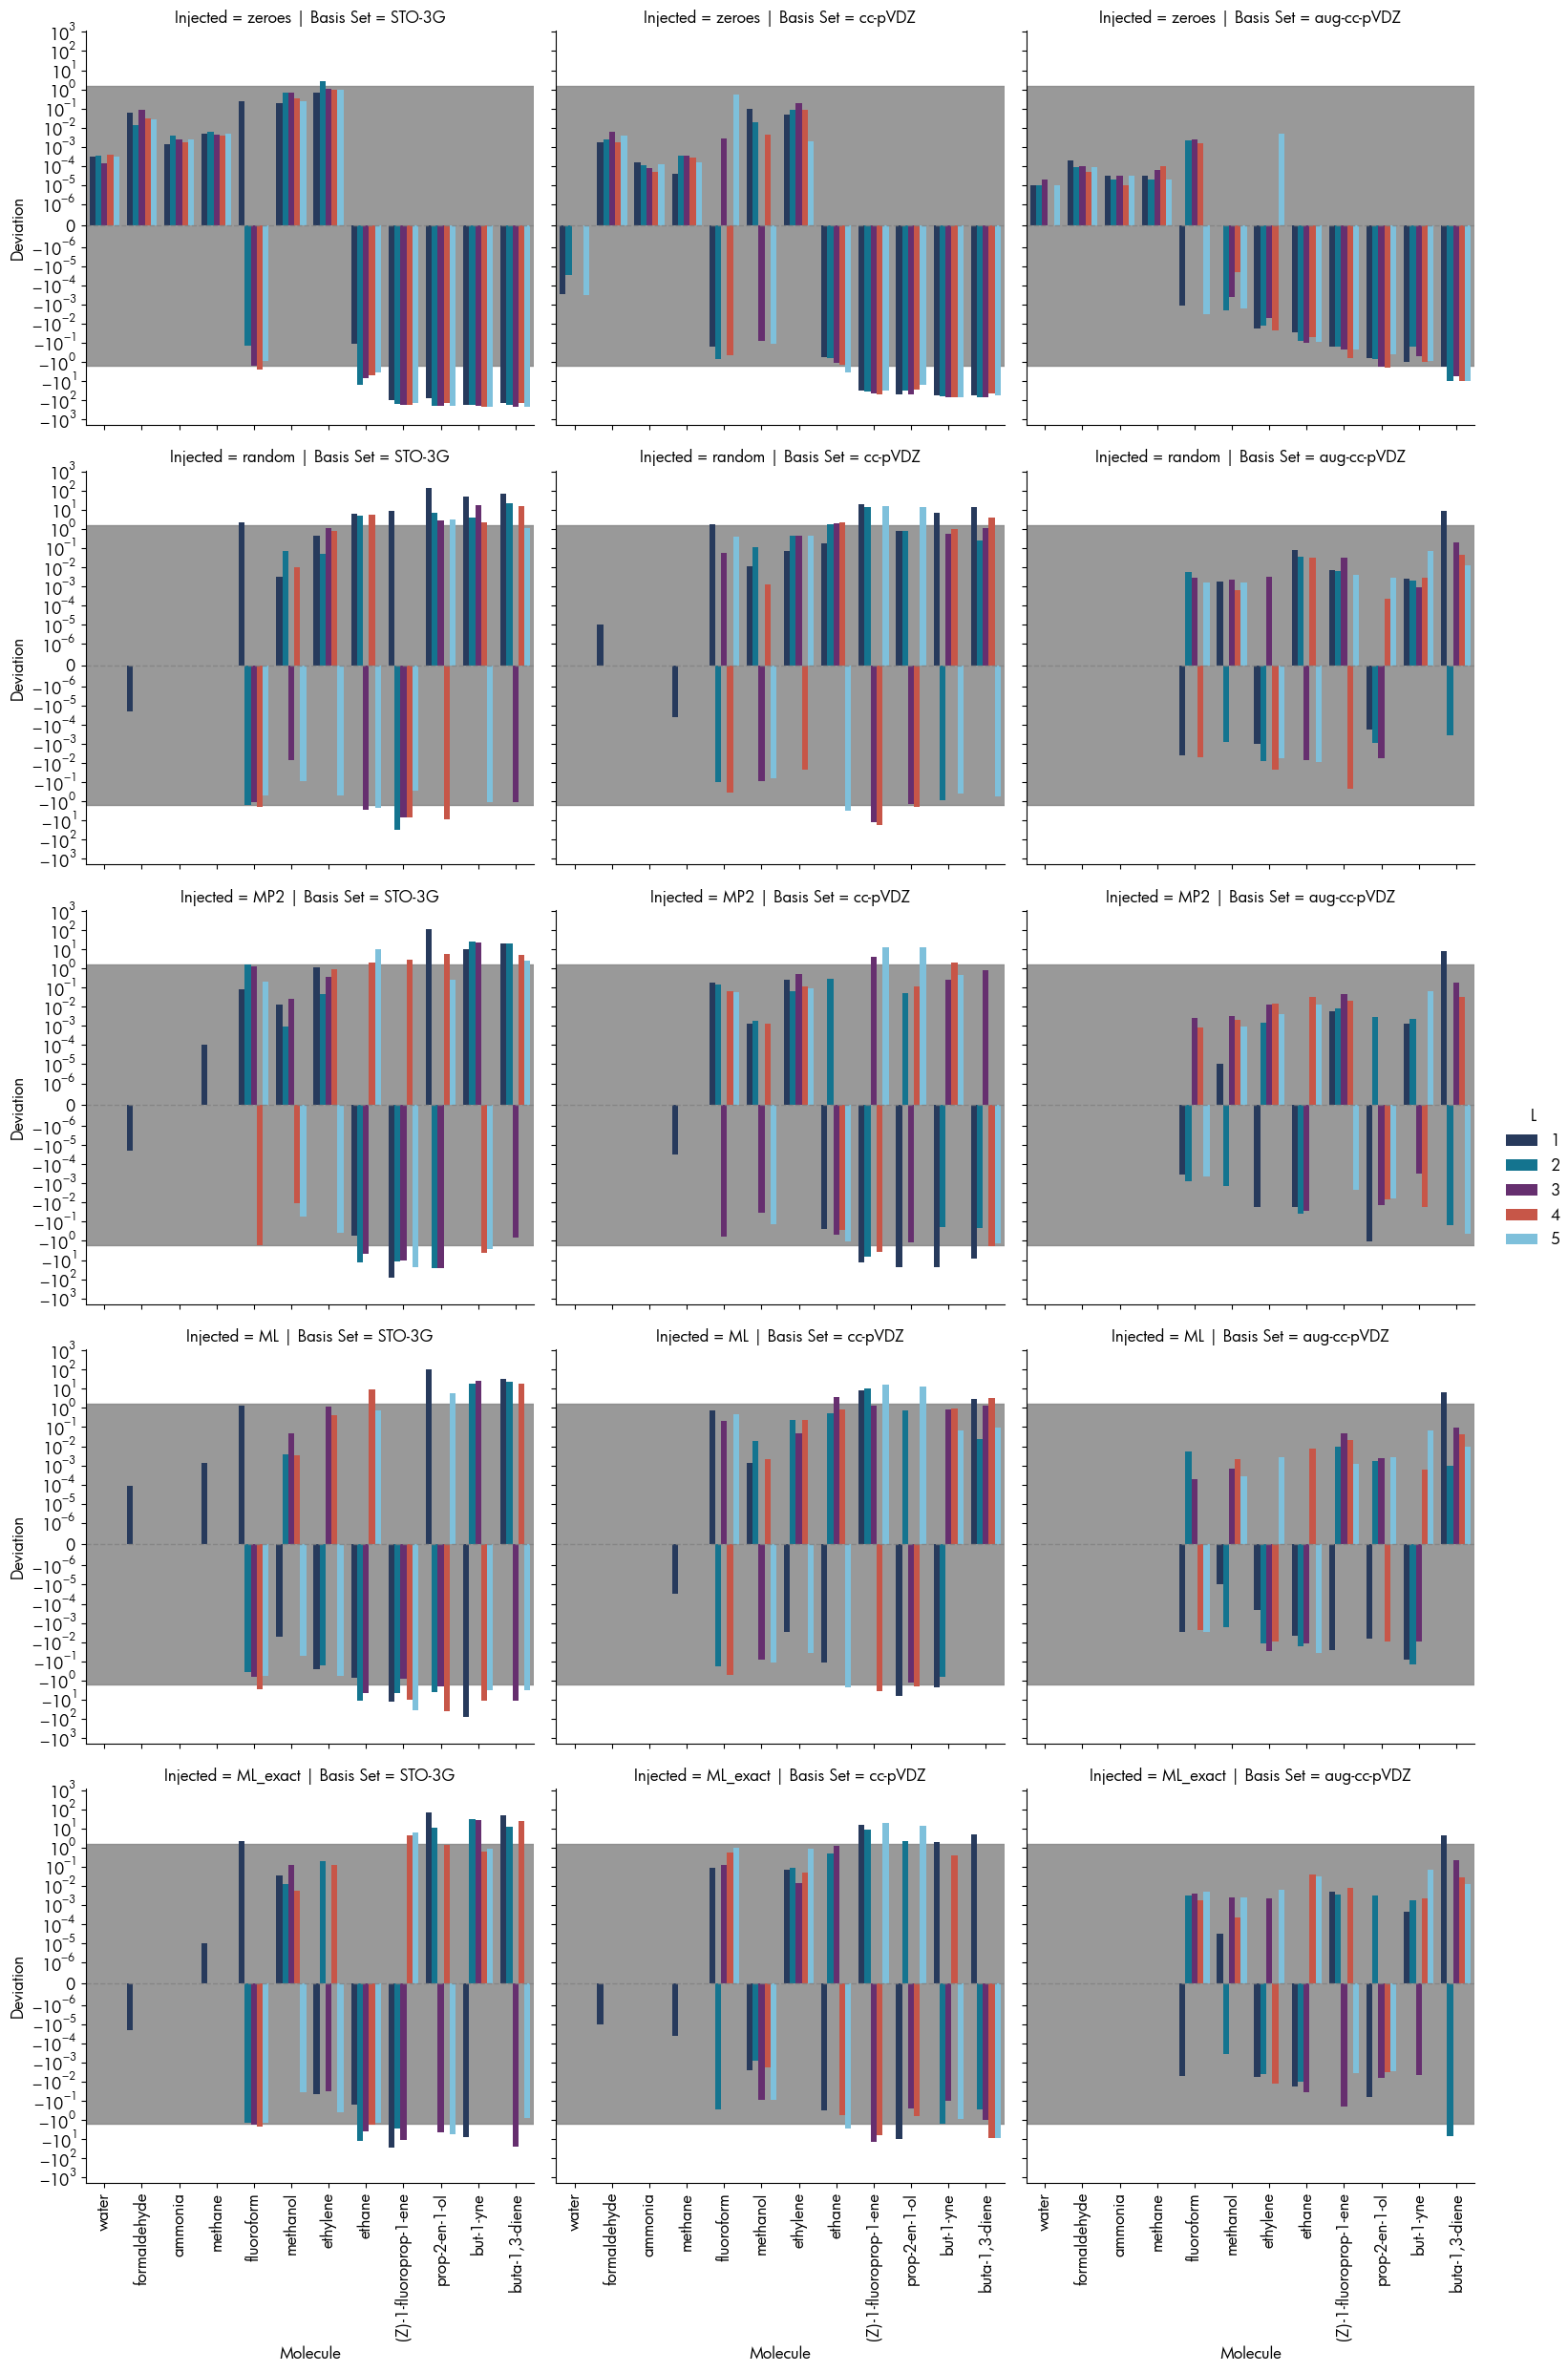

In [24]:
# 1. Generate your catplot and store it in a variable (g)
g = sns.catplot(
    data=findDevCCSD.loc[findDevCCSD['Injected'] != 'CCSD'].sort_values(by=['Basis Set','n_atoms','L']),
    col='Basis Set',
    row='Injected',
    x='Molecule',
    y='Deviation',
    hue='L',
    kind='bar',
    row_order=['zeroes','random','MP2','ML','ML_exact'],
    col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],
    palette=palette
)
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-6)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)  
plt.tight_layout()   
# # 2. Define a helper function to apply the gray span and axis scaling to each facet
# def customize_facet(*args, **kwargs):
#     ax = plt.gca()
#     # Add the gray area for chemical accuracy (~1 kcal/mol or 1.6 mHa depending on your units)
#     ax.axhspan(-1.6, 1.6, color='gray', alpha=0.3, zorder=0) # Lowered alpha to 0.3 so bars remain visible
    
#     # Apply symlog scaling and limits
#     ax.set_yscale("symlog", linthresh=1e-12)
#     ax.set_ylim(-1e3, 1e3)

# # 3. Map the custom function across all subplots in the FacetGrid
# g.map_dataframe(customize_facet)
plt.savefig("./GMJ_figures/DevEnergiesCCSDInitAll.png",dpi=300,bbox_inches='tight')
# Display the plot
plt.show()

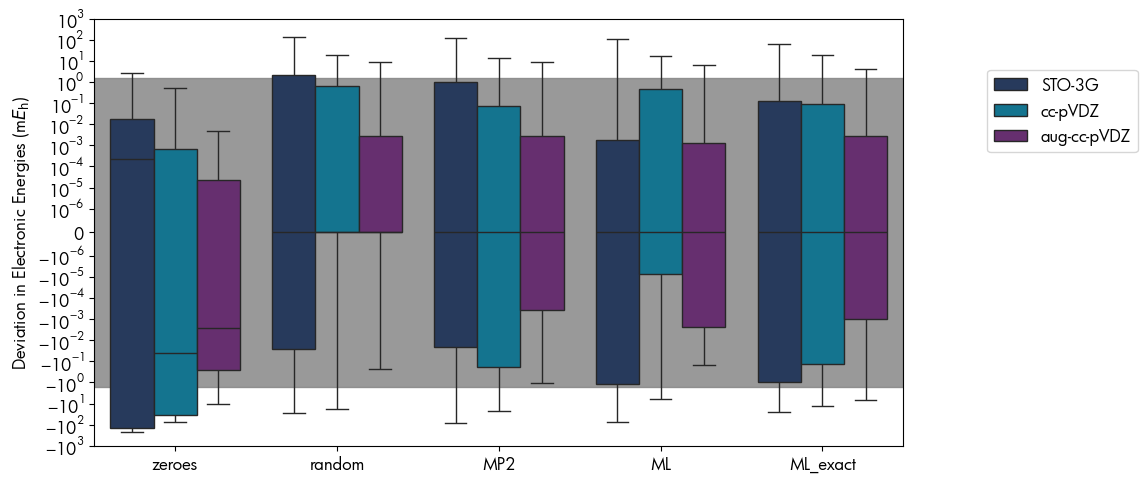

In [25]:

plt.figure(figsize=(12,5))
sns.boxplot(findDevCCSD,x='Injected',y='Deviation',hue='Basis Set',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'],whis=(0, 100))
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.yscale("symlog",linthresh=1e-6)
plt.ylim(-1e3,1e3)
plt.xlabel("")
plt.ylabel(r"Deviation in Electronic Energies (m$E_{\mathrm{h}}$)")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/DevEnergiesCCSDInit.png",dpi=300,bbox_inches='tight')
plt.show()

In [26]:
for inj in uniqueInj:
    for basis in uniqueBasis:
        devdf = findDevCCSD.loc[(findDevCCSD['Injected'] == inj)&(findDevCCSD['Basis Set']==basis),'Deviation']
        print(inj)
        print(devdf.describe().loc[['mean','min','max','std']].map('{:.2e}'.format))
        print(devdf.idxmin(),findDevCCSD.loc[findDevCCSD['Injected'] == inj].loc[devdf.idxmin()])

zeroes
mean    -5.73e+01
min     -2.31e+02
max      2.65e+00
std      8.40e+01
Name: Deviation, dtype: object
1038 Basis Set        STO-3G
Molecule      but-1-yne
L                     5
Injected         zeroes
Energy      -153.259322
n_atoms              10
Deviation    -231.16019
Name: 1038, dtype: object
zeroes
mean    -1.66e+01
min     -7.39e+01
max      5.22e-01
std      2.54e+01
Name: Deviation, dtype: object
737 Basis Set       cc-pVDZ
Molecule      but-1-yne
L                     3
Injected         zeroes
Energy      -154.986102
n_atoms              10
Deviation     -73.86788
Name: 737, dtype: object
zeroes
mean    -8.23e-01
min     -1.03e+01
max      4.81e-03
std      2.35e+00
Name: Deviation, dtype: object
557 Basis Set       aug-cc-pVDZ
Molecule     buta-1,3-diene
L                         2
Injected             zeroes
Energy          -154.950256
n_atoms                  10
Deviation         -10.34143
Name: 557, dtype: object
random
mean     4.81e+00
min     -2.89e+01
max   

In [27]:
# 1. Individual dictionaries for each level (summary stats)
basis_mae = {}
mol_mae = {}
inj_mae = {}
layer_mae = {}

# 2. The master compiled dictionary (nested)
all_mae = {}

for basis in uniqueBasis:
    b_mask = (LUCJDF['Basis Set'] == basis)
    basis_mae[basis] = mean_absolute_error(LUCJDF.loc[b_mask, 'Energy'], LUCJDF.loc[b_mask, 'Energy (HCI)']) * 1e3
    
    all_mae[basis] = {} # Initialize next level
    
    for mol in uniqueMol:
        m_mask = (LUCJDF['Molecule'] == mol)
        # Unique dict for molecules (could use a tuple key to keep it unique across basis sets)
        mol_mae[(basis, mol)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask, 'Energy (HCI)']) * 1e3
        
        all_mae[basis][mol] = {}
        
        for inj in uniqueInj:
            i_mask = (LUCJDF['Injected'] == inj)
            inj_mae[(basis, mol, inj)] = mean_absolute_error(LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy'], LUCJDF.loc[b_mask & m_mask & i_mask, 'Energy (HCI)']) * 1e3
            
            all_mae[basis][mol][inj] = {}
            
            for L in uniqueLayers:
                l_mask = (LUCJDF['L'] == L)
                
                # Check to avoid errors if a specific slice is empty
                subset = LUCJDF.loc[b_mask & m_mask & i_mask & l_mask]
                if not subset.empty:
                    mae_val = mean_absolute_error(subset['Energy'], subset['Energy (HCI)']) * 1e3
                    
                    # Store in unique flat dict
                    layer_mae[(basis, mol, inj, L)] = mae_val
                    
                    # Store in the compiled nested dict
                    all_mae[basis][mol][inj][L] = mae_val

# 1. Basis MAE (Keys are single strings)
basis_mae_df = pd.DataFrame(list(basis_mae.items()), 
                            columns=['Basis', 'MAE'])

# 2. Molecule MAE (Keys are tuples: (basis, mol))
mol_mae_df = pd.DataFrame([(*k, v) for k, v in mol_mae.items()], 
                          columns=['Basis', 'Molecule', 'MAE'])

# 3. Injected MAE (Keys are tuples: (basis, mol, inj))
inj_mae_df = pd.DataFrame([(*k, v) for k, v in inj_mae.items()], 
                          columns=['Basis', 'Molecule', 'Injected', 'MAE'])

# 4. Layer MAE (Keys are tuples: (basis, mol, inj, L))
layer_mae_df = pd.DataFrame([(*k, v) for k, v in layer_mae.items()], 
                            columns=['Basis', 'Molecule', 'Injected', 'L', 'MAE'])                    

/tmp/ipykernel_20688/2530434211.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)


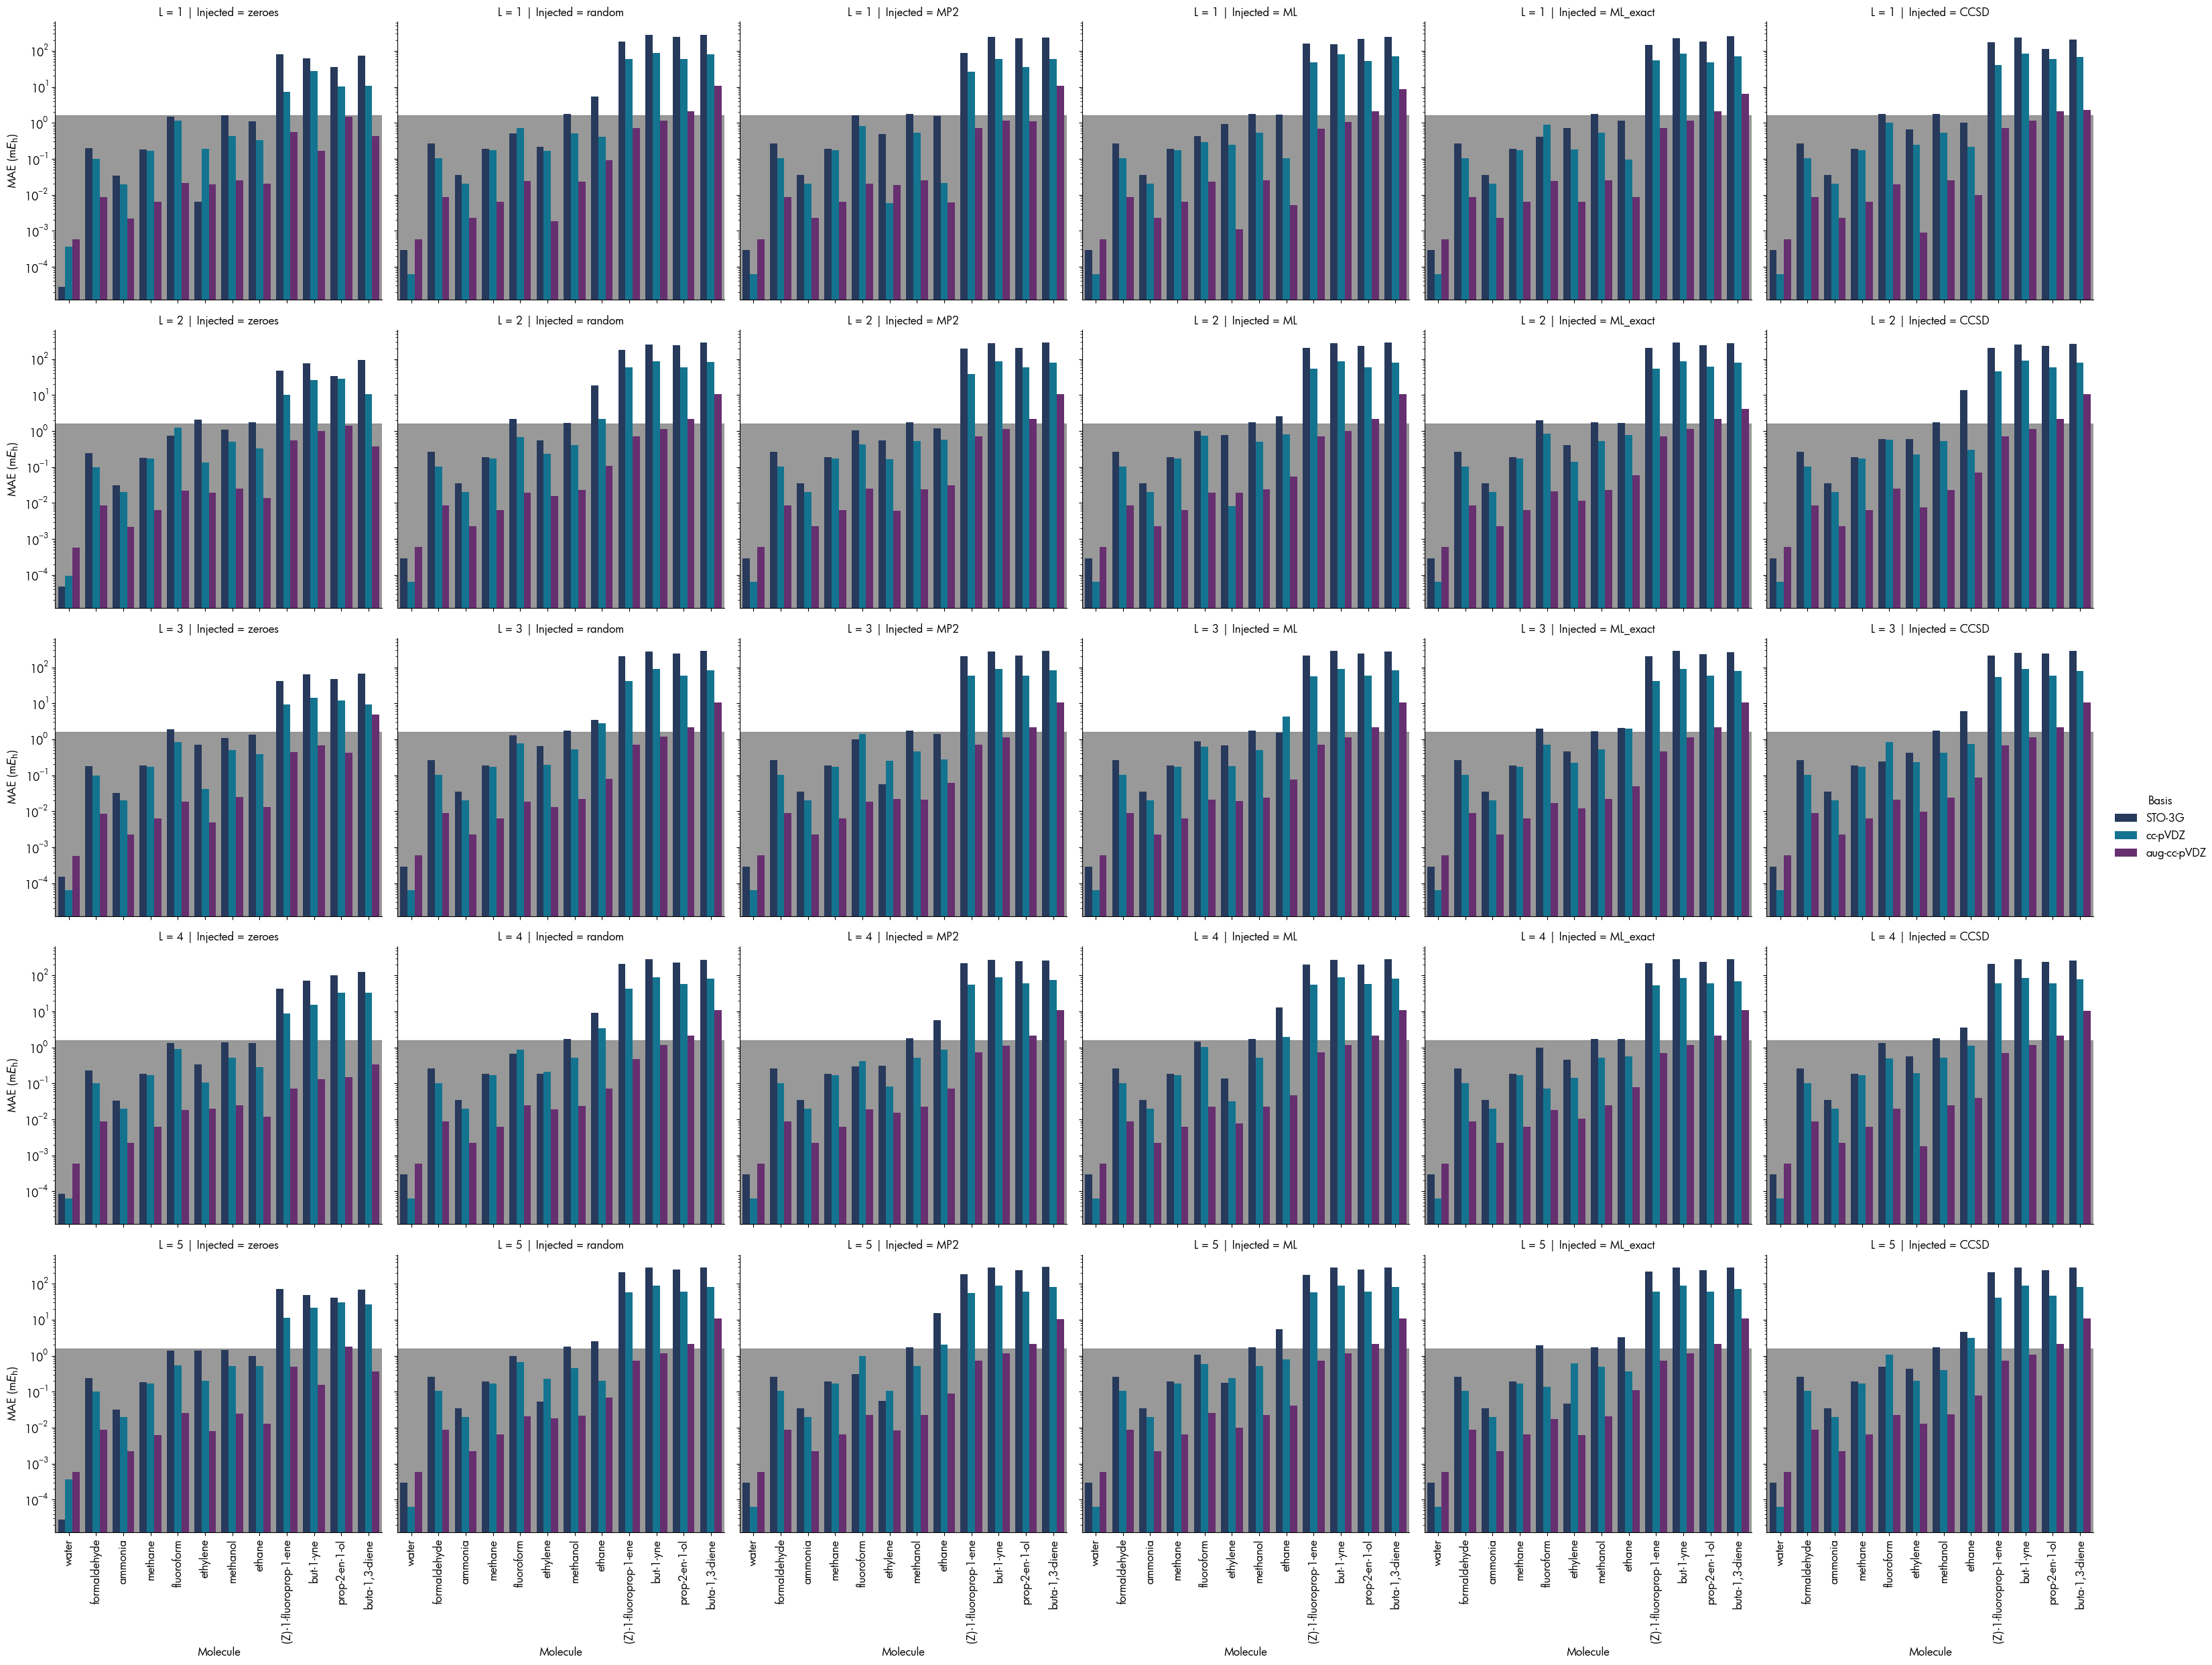

In [28]:
g = sns.catplot(data=layer_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',row='L',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis_layer.png",dpi=300,bbox_inches='tight')

/tmp/ipykernel_20688/1137384109.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)


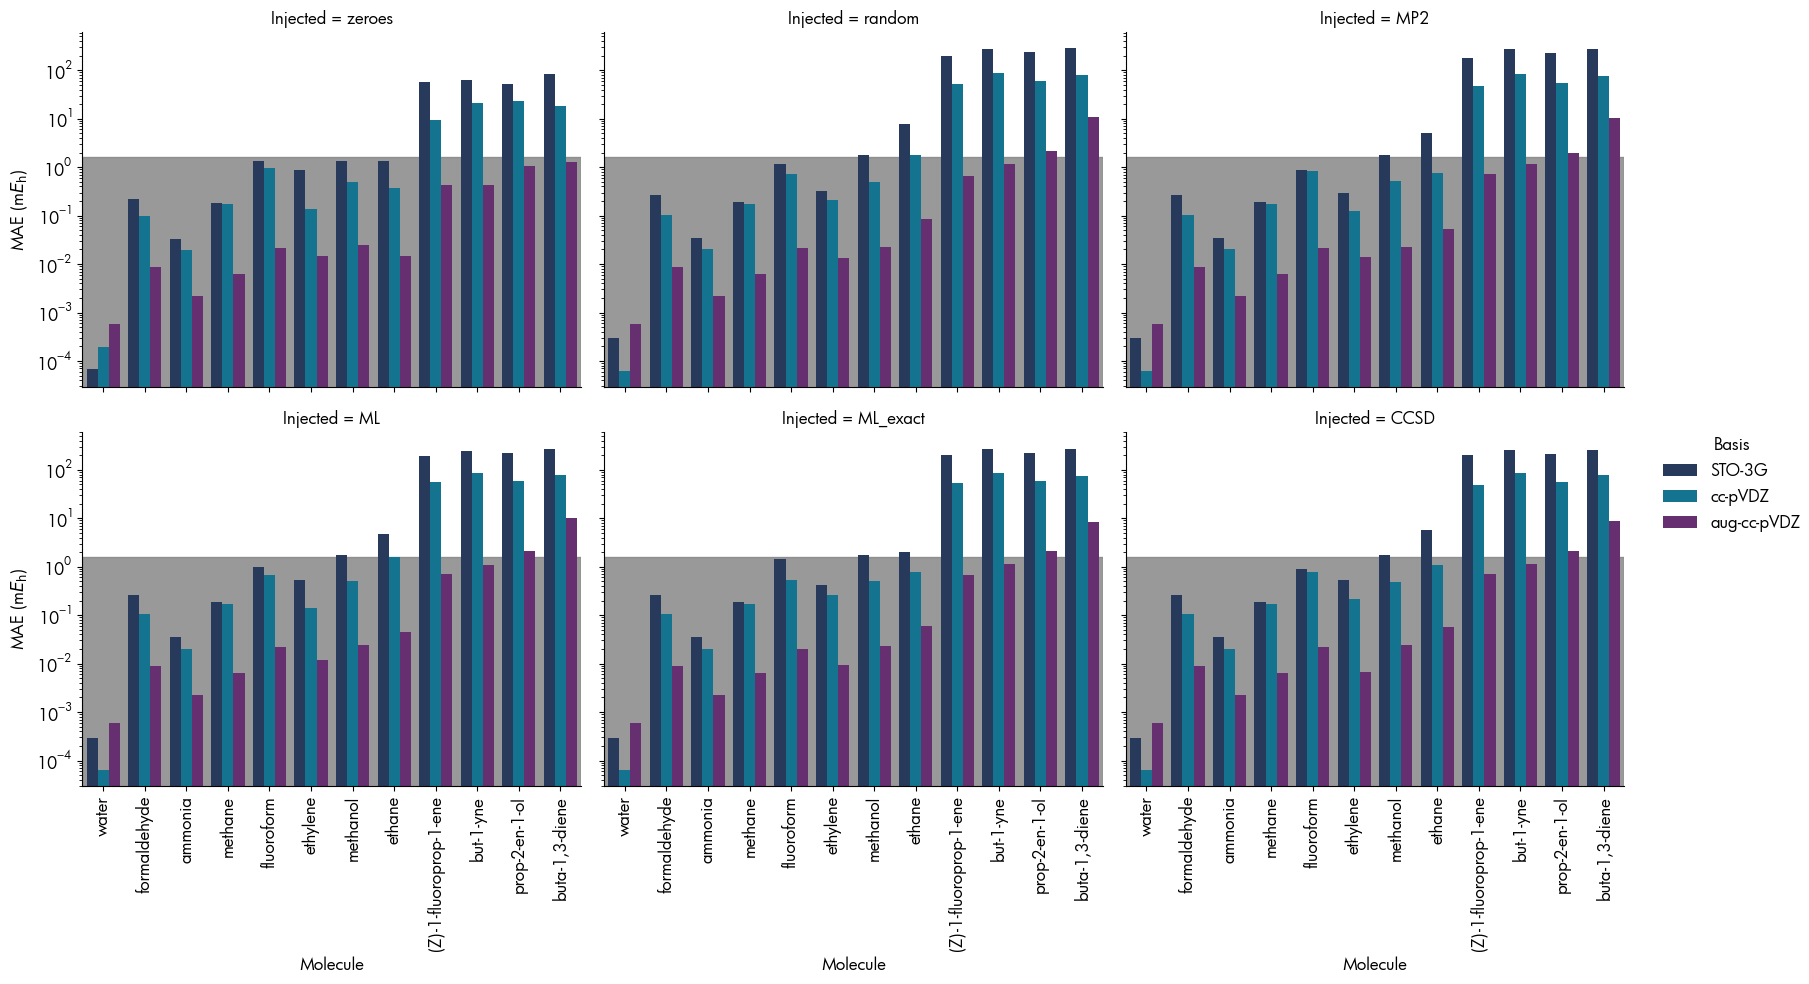

In [29]:
g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)        
# plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5))        
plt.tight_layout()        
plt.savefig("GMJ_figures/MAE_inj_mol_basis.png",dpi=300,bbox_inches='tight')

/tmp/ipykernel_20688/2938803511.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)


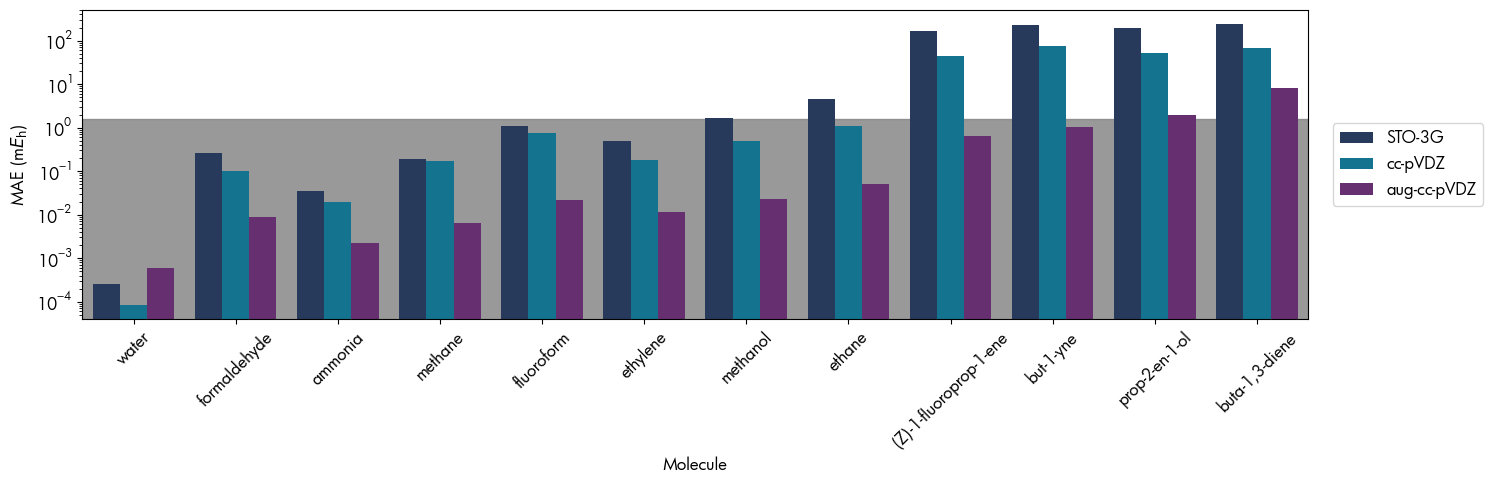

In [30]:
plt.figure(figsize=(15,5))
sns.barplot(data=mol_mae_df,x='Molecule',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette)
plt.yscale("log")
plt.ylabel(r"MAE (m$E_{\mathrm{h}}$)")
plt.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
plt.xticks(rotation=45)
plt.legend(loc='center right', bbox_to_anchor=(1.15, 0.5))
plt.tight_layout()
plt.savefig("GMJ_figures/MAE_mol_basis.png",dpi=300,bbox_inches='tight')

In [31]:
for basis, inj in product(uniqueBasis,uniqueInj):
    mask = (LUCJDF['Basis Set']==basis)&(LUCJDF['Injected']==inj)
    print(f"{basis} {inj} {mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)'])*1e3:.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


In [32]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (HCI)']):.2f} mEh")
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (HCI)']):.2f} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (HCI)']):.2f} mEh")

STO-3G zeroes 21.87 mEh
STO-3G random 83.81 mEh
STO-3G MP2 79.53 mEh
STO-3G ML 79.16 mEh
STO-3G ML_exact 81.18 mEh
STO-3G CCSD 79.01 mEh
cc-pVDZ zeroes 6.13 mEh
cc-pVDZ random 23.69 mEh
cc-pVDZ MP2 21.84 mEh
cc-pVDZ ML 23.46 mEh
cc-pVDZ ML_exact 22.83 mEh
cc-pVDZ CCSD 22.68 mEh
aug-cc-pVDZ zeroes 0.27 mEh
aug-cc-pVDZ random 1.24 mEh
aug-cc-pVDZ MP2 1.21 mEh
aug-cc-pVDZ ML 1.19 mEh
aug-cc-pVDZ ML_exact 1.05 mEh
aug-cc-pVDZ CCSD 1.09 mEh


In [33]:
for basis in uniqueBasis:
    basismask = (LUCJDF['Basis Set'] == basis)&(~LUCJDF['Energy (CASCI)'].isna())
    # print(basis, f"{1e3*mean_absolute_error(LUCJDF.loc[basismask,'Energy'],LUCJDF.loc[basismask,'Energy (CASCI)']):.2f} mEh")
    # print(LUCJDF.loc[basismask,'Molecule'].unique())
    for inj in uniqueInj:
        injmask = basismask&(LUCJDF['Injected'] == inj)
        print(basis, inj, f"{1e3*mean_absolute_error(LUCJDF.loc[injmask,'Energy'],LUCJDF.loc[injmask,'Energy (CASCI)']):.2e} mEh")
        # for layers in sorted(uniqueLayers):
        #     mask = injmask&(LUCJDF['L'] == layers)
        #     print(basis, inj, layers, f"{1e3*mean_absolute_error(LUCJDF.loc[mask,'Energy'],LUCJDF.loc[mask,'Energy (CASCI)']):.2f} mEh")

STO-3G zeroes 8.47e-01 mEh
STO-3G random 1.91e+00 mEh
STO-3G MP2 1.41e+00 mEh
STO-3G ML 1.33e+00 mEh
STO-3G ML_exact 9.46e-01 mEh
STO-3G CCSD 1.51e+00 mEh
cc-pVDZ zeroes 8.60e-02 mEh
cc-pVDZ random 4.23e-01 mEh
cc-pVDZ MP2 2.59e-01 mEh
cc-pVDZ ML 3.66e-01 mEh
cc-pVDZ ML_exact 2.57e-01 mEh
cc-pVDZ CCSD 2.85e-01 mEh
aug-cc-pVDZ zeroes 2.17e-03 mEh
aug-cc-pVDZ random 1.70e-02 mEh
aug-cc-pVDZ MP2 1.34e-02 mEh
aug-cc-pVDZ ML 1.08e-02 mEh
aug-cc-pVDZ ML_exact 1.38e-02 mEh
aug-cc-pVDZ CCSD 1.39e-02 mEh


In [34]:
ampdf = pd.read_excel("amplitude_data.xlsx",index_col=0).rename(columns={'molecule':'Molecule','basis':'Basis Set','Amplitude':'Injected'})
ampdf['Injected'] = [i.replace("t2_rand","random") if i=='t2_rand' else i.replace("t2_","") for i in ampdf['Injected']]
uniAmpCol = [i for i in ampdf.columns if i not in LUCJDF.columns]
# uniLUCCol = [i for i in LUCJDF.columns if i not in ampdf.columns]

stackedamp = []
for basis, inj, layer, mol in product(uniqueBasis, uniqueInj, uniqueLayers, uniqueMol):
    ampmask = (ampdf['Molecule']==mol) & (ampdf['Basis Set']==basis) & (ampdf['Injected']==inj)
    lucjdfmask = (LUCJDF['Molecule']==mol) & (LUCJDF['Basis Set']==basis) & (LUCJDF['Injected']==inj) & (LUCJDF['L']==layer)

    tmplucj = LUCJDF.loc[lucjdfmask, :].reset_index(drop=True)
    tmpamp = ampdf.loc[ampmask, uniAmpCol].reset_index(drop=True)
    
    combined = pd.concat([tmplucj, tmpamp], axis=1)
    
    stackedamp.append(combined)
stackedamp = pd.concat(stackedamp).reset_index(drop=True)
stackedamp.fillna(0,inplace=True)

In [35]:
# Save bad ones

bad_df = LUCJDF[((LUCJDF['Energy (HCI)'] - LUCJDF['Energy']).abs()*1e3)>=1.6]


# bad_df.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")
LUCJDF.sort_values(by=['Molecule','Basis Set','L',"Injected"]).reset_index(drop=True).to_excel("repostprocess.xlsx")

In [36]:
with open("rerun_trash.sh",'w') as f:
    for _, row in LUCJDF.loc[LUCJDF['Energy']<-1e4,['Basis Set','Molecule','L','Injected']].iterrows():
        basis, name, layer, injection = row.to_list()
        filename = f"{name}_LUCJ_L{layer}_{basis}_{injection}.sh"
        if os.path.exists(os.path.join('postprocess',filename)) is False:
            print(filename)
        else:
            f.write(filename+"\n")

/tmp/ipykernel_20688/1614905520.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(data=LUCJDF.sort_values(by=['Basis Set','L','n_atoms','Injected']),hue='L',y='Deviation',row='Injected',col='Basis Set',kind='bar',x='Molecule',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],row_order=uniqueInj,palette=palette)


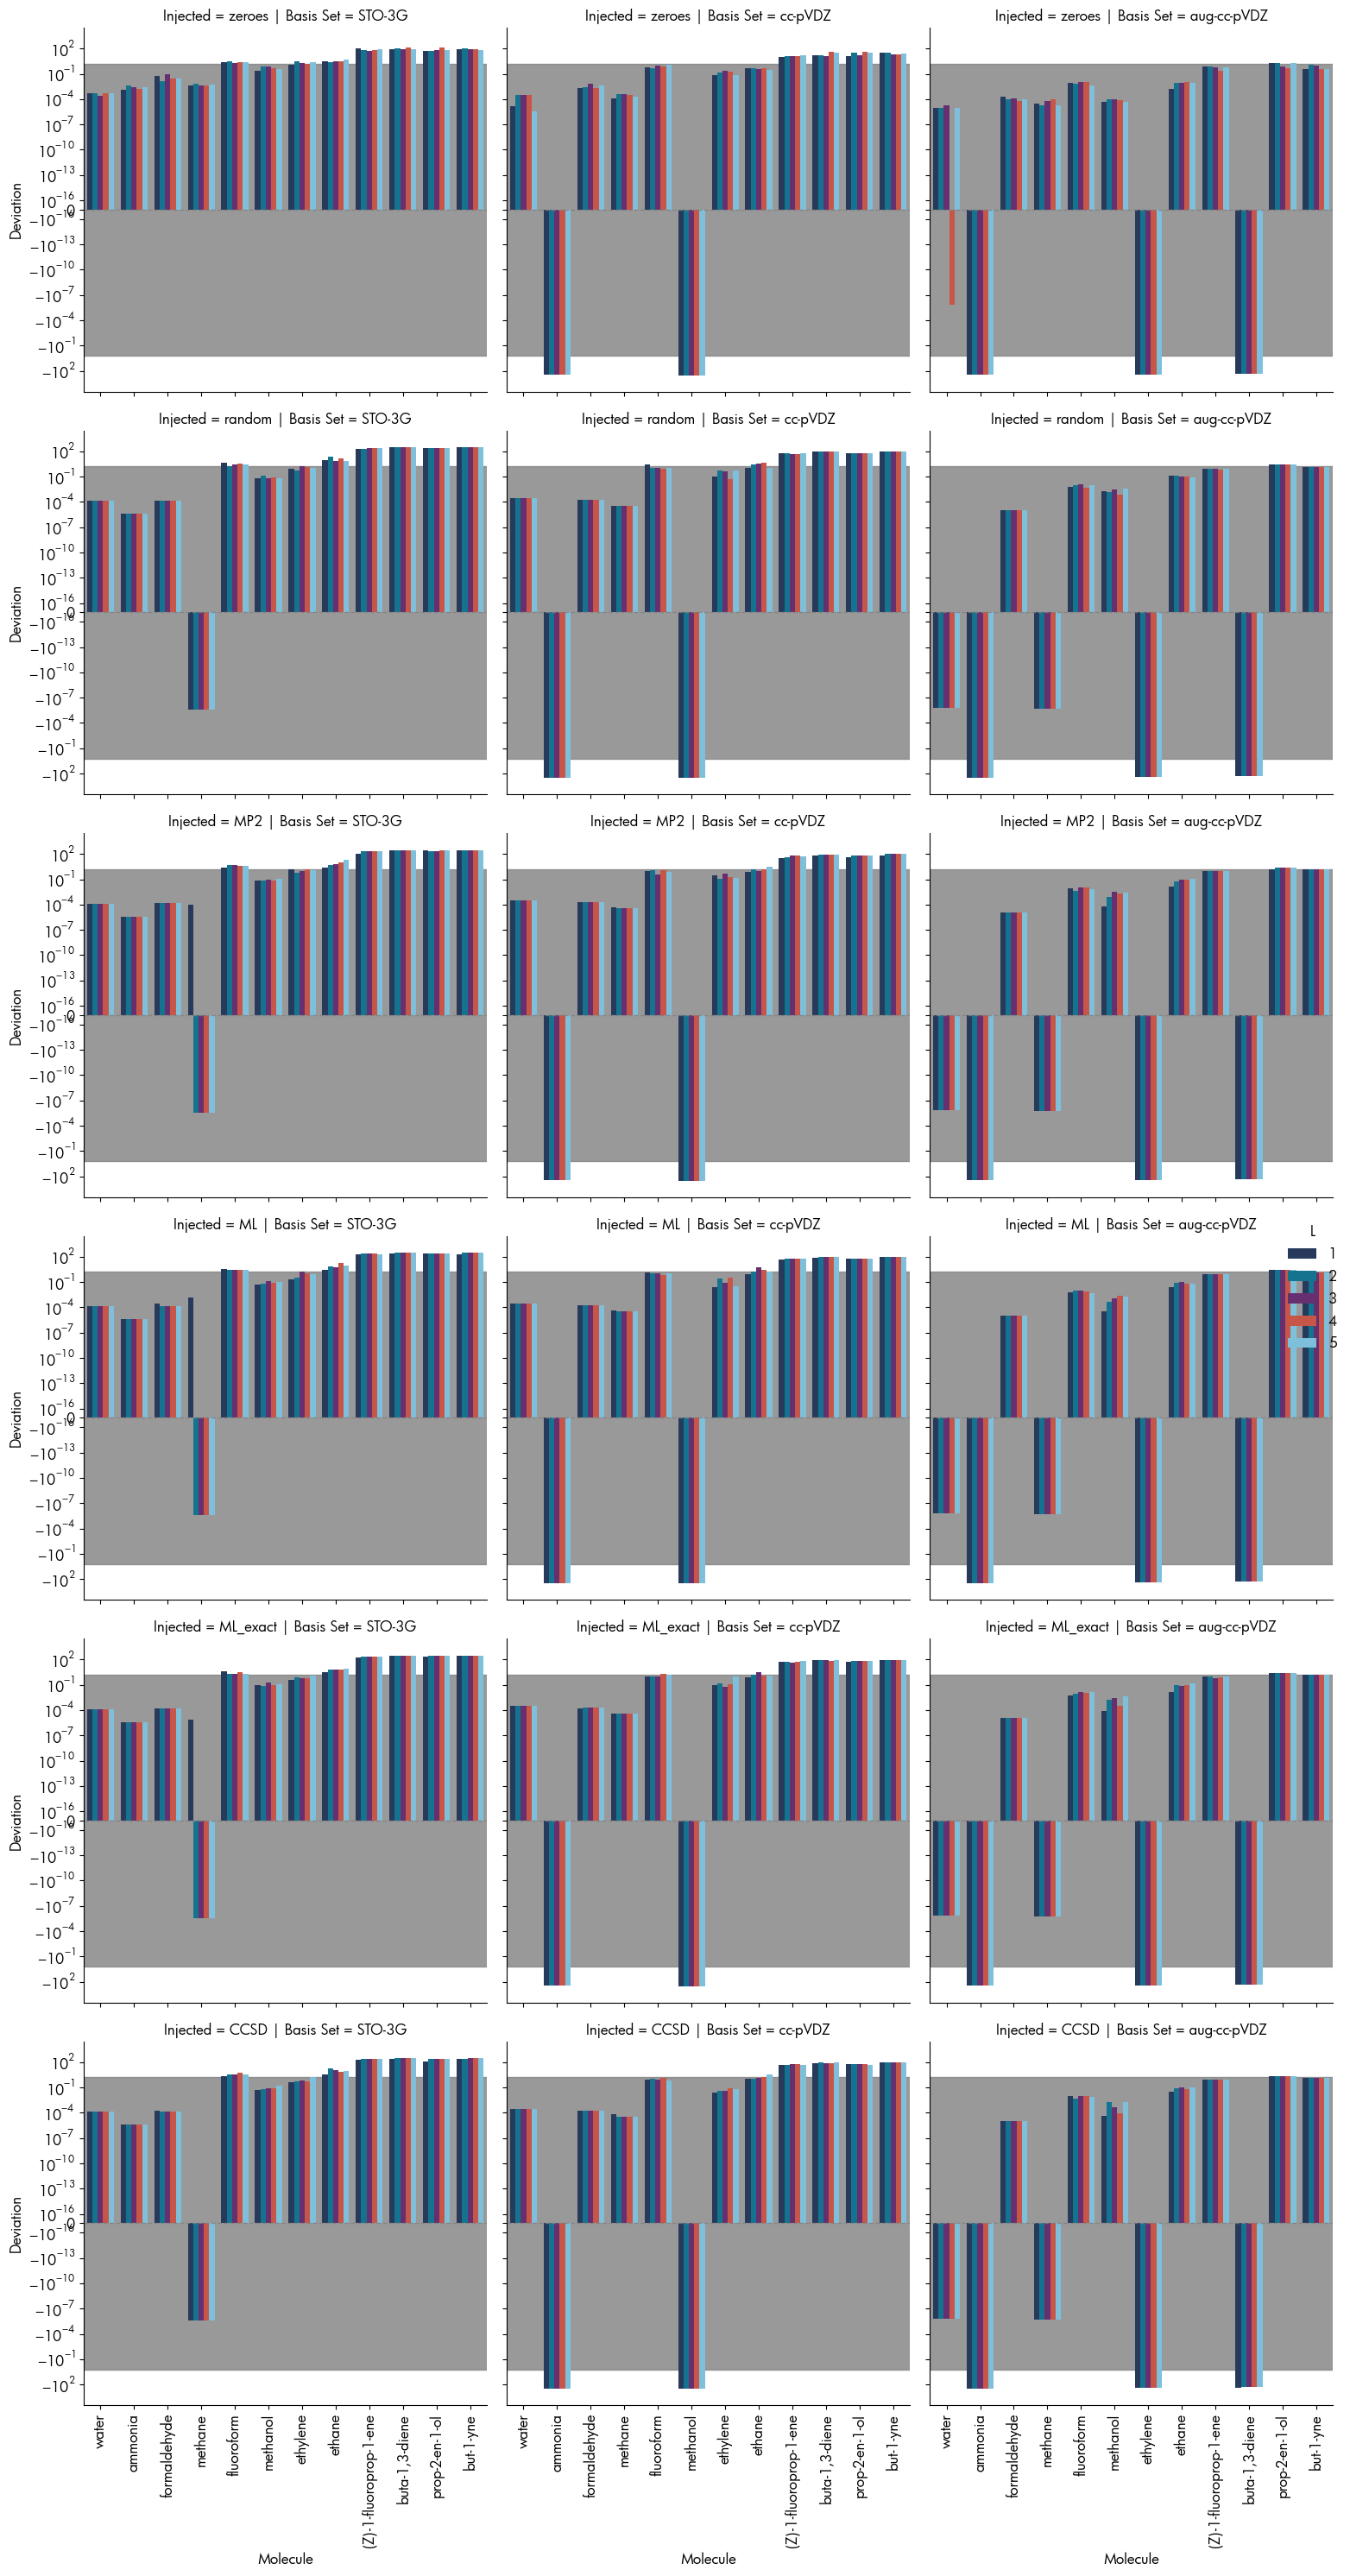

In [37]:
g = sns.catplot(data=LUCJDF.sort_values(by=['Basis Set','L','n_atoms','Injected']),hue='L',y='Deviation',row='Injected',col='Basis Set',kind='bar',x='Molecule',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],row_order=uniqueInj,palette=palette)
# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-16)
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")
plt.tight_layout()        
plt.savefig("GMJ_figures/deviations.png",dpi=300,bbox_inches='tight')

In [38]:
LUCJDF['Deviation'].describe()

count    1080.000000
mean       -6.032311
std       135.028724
min      -319.190527
25%         0.000011
50%         0.070789
75%         3.781470
max       306.347182
Name: Deviation, dtype: float64

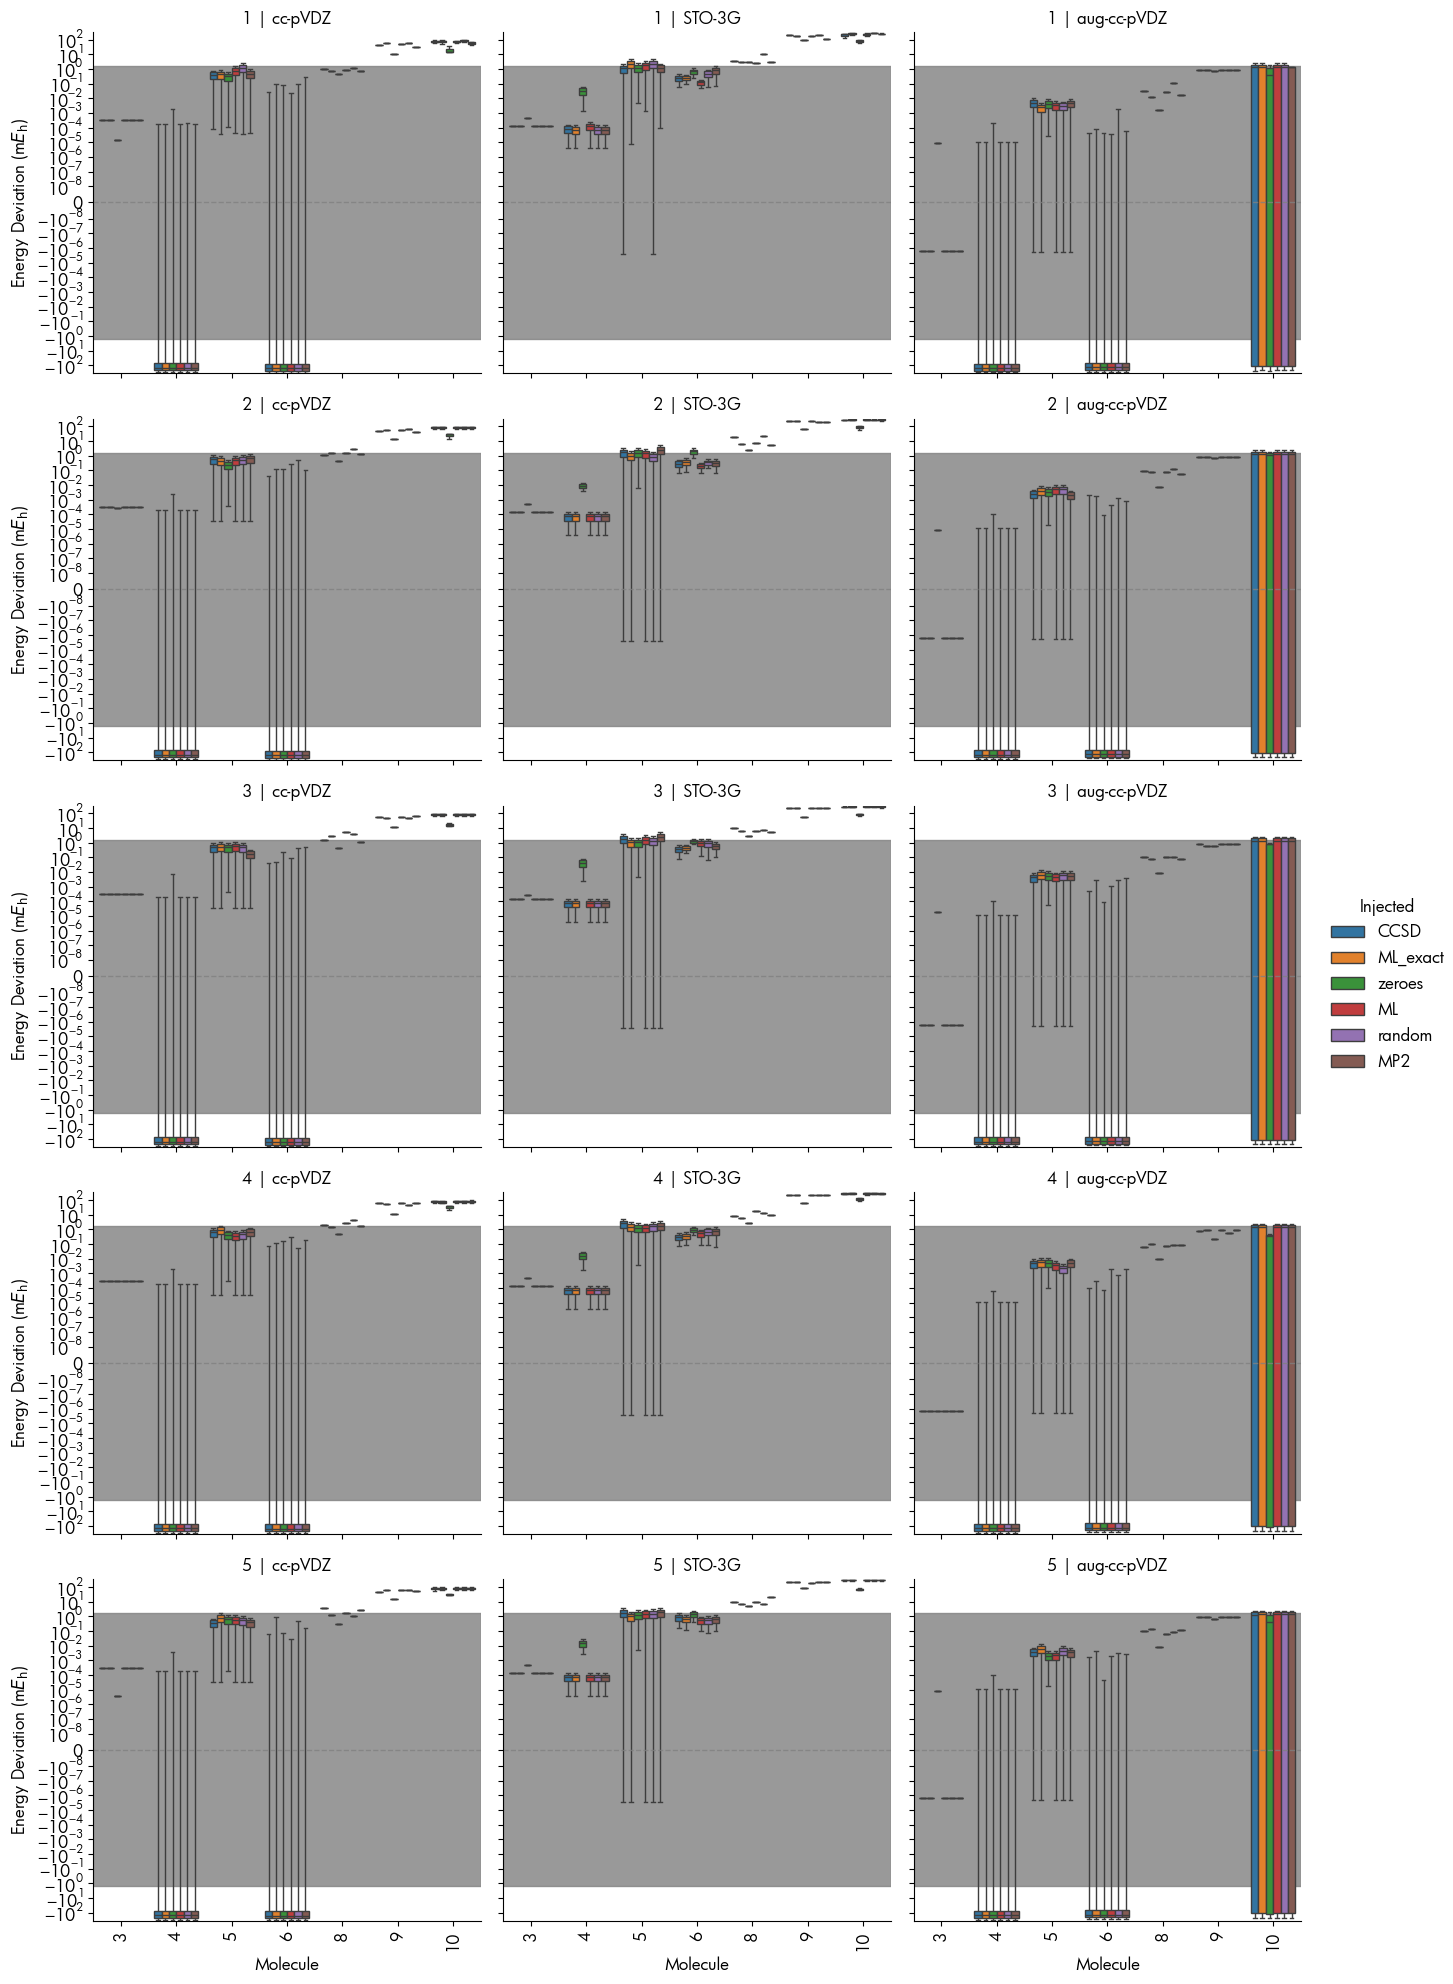

In [39]:
g = sns.catplot(LUCJDF,
                col='Basis Set',
                row='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.1 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.show()

In [40]:
LUCJDF['Deviation'].max(),LUCJDF['Deviation'].min()

(np.float64(306.3471822438828), np.float64(-319.19052740070697))

# Deviation from CCSD initialized

In [41]:
for basis, layer, mol in product(uniqueBasis,uniqueLayers,uniqueMol):
    mask = ((LUCJDF['Basis Set']==basis) &
            (LUCJDF['L']==layer) &
            (LUCJDF['Molecule']==mol) 
           
           )
    print(mol,basis)
    LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - LUCJDF.loc[mask&(LUCJDF['Injected']=='CCSD'),'Energy'].values)*1e3
    # try:
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3
    # except:
    #     mol = moldf.loc[moldf['molecule'] == mol,'mol_filename'].values[0].replace('.xyz','')
    #     LUCJDF.loc[mask,'Deviation'] = (LUCJDF.loc[mask,"Energy"] - energyDF.loc[(energyDF['Molecule']==mol)&(energyDF['Basis Set']==basis)&(energyDF['Method']=='SHCI'),'Energy'].values[0])*1e3

water STO-3G
formaldehyde STO-3G
ammonia STO-3G
methane STO-3G
fluoroform STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
prop-2-en-1-ol STO-3G
buta-1,3-diene STO-3G
water STO-3G
formaldehyde STO-3G
ammonia STO-3G
methane STO-3G
fluoroform STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
prop-2-en-1-ol STO-3G
buta-1,3-diene STO-3G
water STO-3G
formaldehyde STO-3G
ammonia STO-3G
methane STO-3G
fluoroform STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
prop-2-en-1-ol STO-3G
buta-1,3-diene STO-3G
water STO-3G
formaldehyde STO-3G
ammonia STO-3G
methane STO-3G
fluoroform STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(Z)-1-fluoroprop-1-ene STO-3G
but-1-yne STO-3G
prop-2-en-1-ol STO-3G
buta-1,3-diene STO-3G
water STO-3G
formaldehyde STO-3G
ammonia STO-3G
methane STO-3G
fluoroform STO-3G
ethylene STO-3G
methanol STO-3G
ethane STO-3G
(

In [42]:
LUCJDF.loc[LUCJDF['Deviation'].idxmax()]

Basis Set                      STO-3G
Molecule               prop-2-en-1-ol
Method                      LUCJ(L=1)
L                                   1
Injected                       random
Energy                    -189.482689
n_atoms                            10
Deviation                   131.53918
Energy (HCI)              -189.727016
Energy (HF)               -189.480427
Energy (CASCI)                    NaN
Energy (DMRG-CASCI)       -189.749396
Name: 154, dtype: object

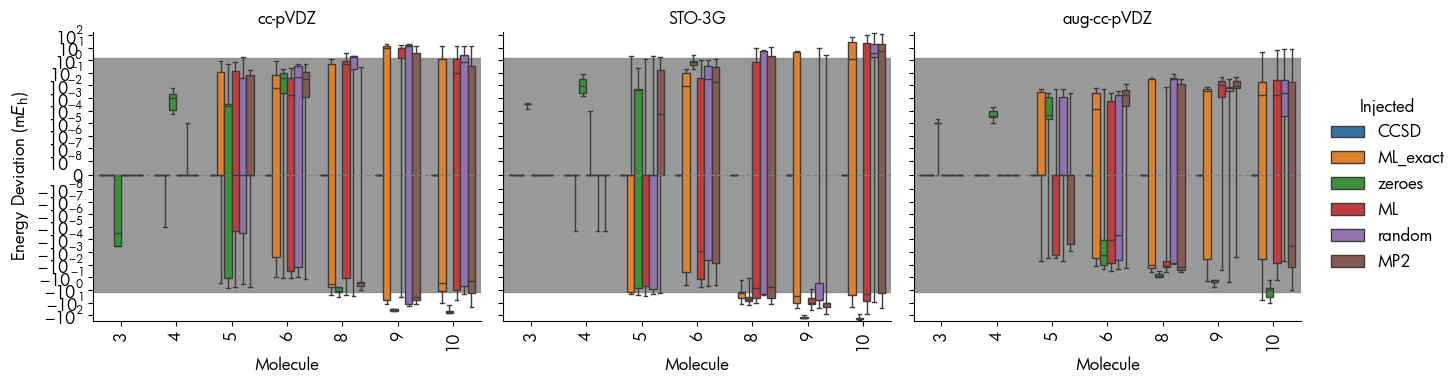

In [43]:
g = sns.catplot(LUCJDF, #[LUCJDF['Injected']!='CCSD'],
                col='Basis Set',
                # col='L',
                x='n_atoms',
                y='Deviation',
                hue='Injected',
                kind='box',
                height=4, 
                # aspect=0.6,
                whis=(0, 100),
                )


# Compute global deviation range for consistent shading/scaling
ymin = LUCJDF["Deviation"].min()
ymax = LUCJDF["Deviation"].max()
pad = 0.2 * max(abs(ymin), abs(ymax))

# Apply styling to **all subplots**
for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=1e-8)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

# Adjust titles and axis labels
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Molecule", r"Energy Deviation (m$E_{\mathrm{h}}$)")


# Move legend outside the main plot (right side)
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_frame_on(False)
plt.subplots_adjust(right=0.85)  # make space for legend

plt.tight_layout()
plt.tight_layout()        
plt.savefig("GMJ_figures/deviationfromccsd.png",dpi=300,bbox_inches='tight')

In [44]:
uniqueBasis = LUCJDF['Basis Set'].unique()
uniqueMol = LUCJDF['Molecule'].unique()
uniqueInj = LUCJDF['Injected'].unique()
uniqueLayers = LUCJDF['L'].unique()


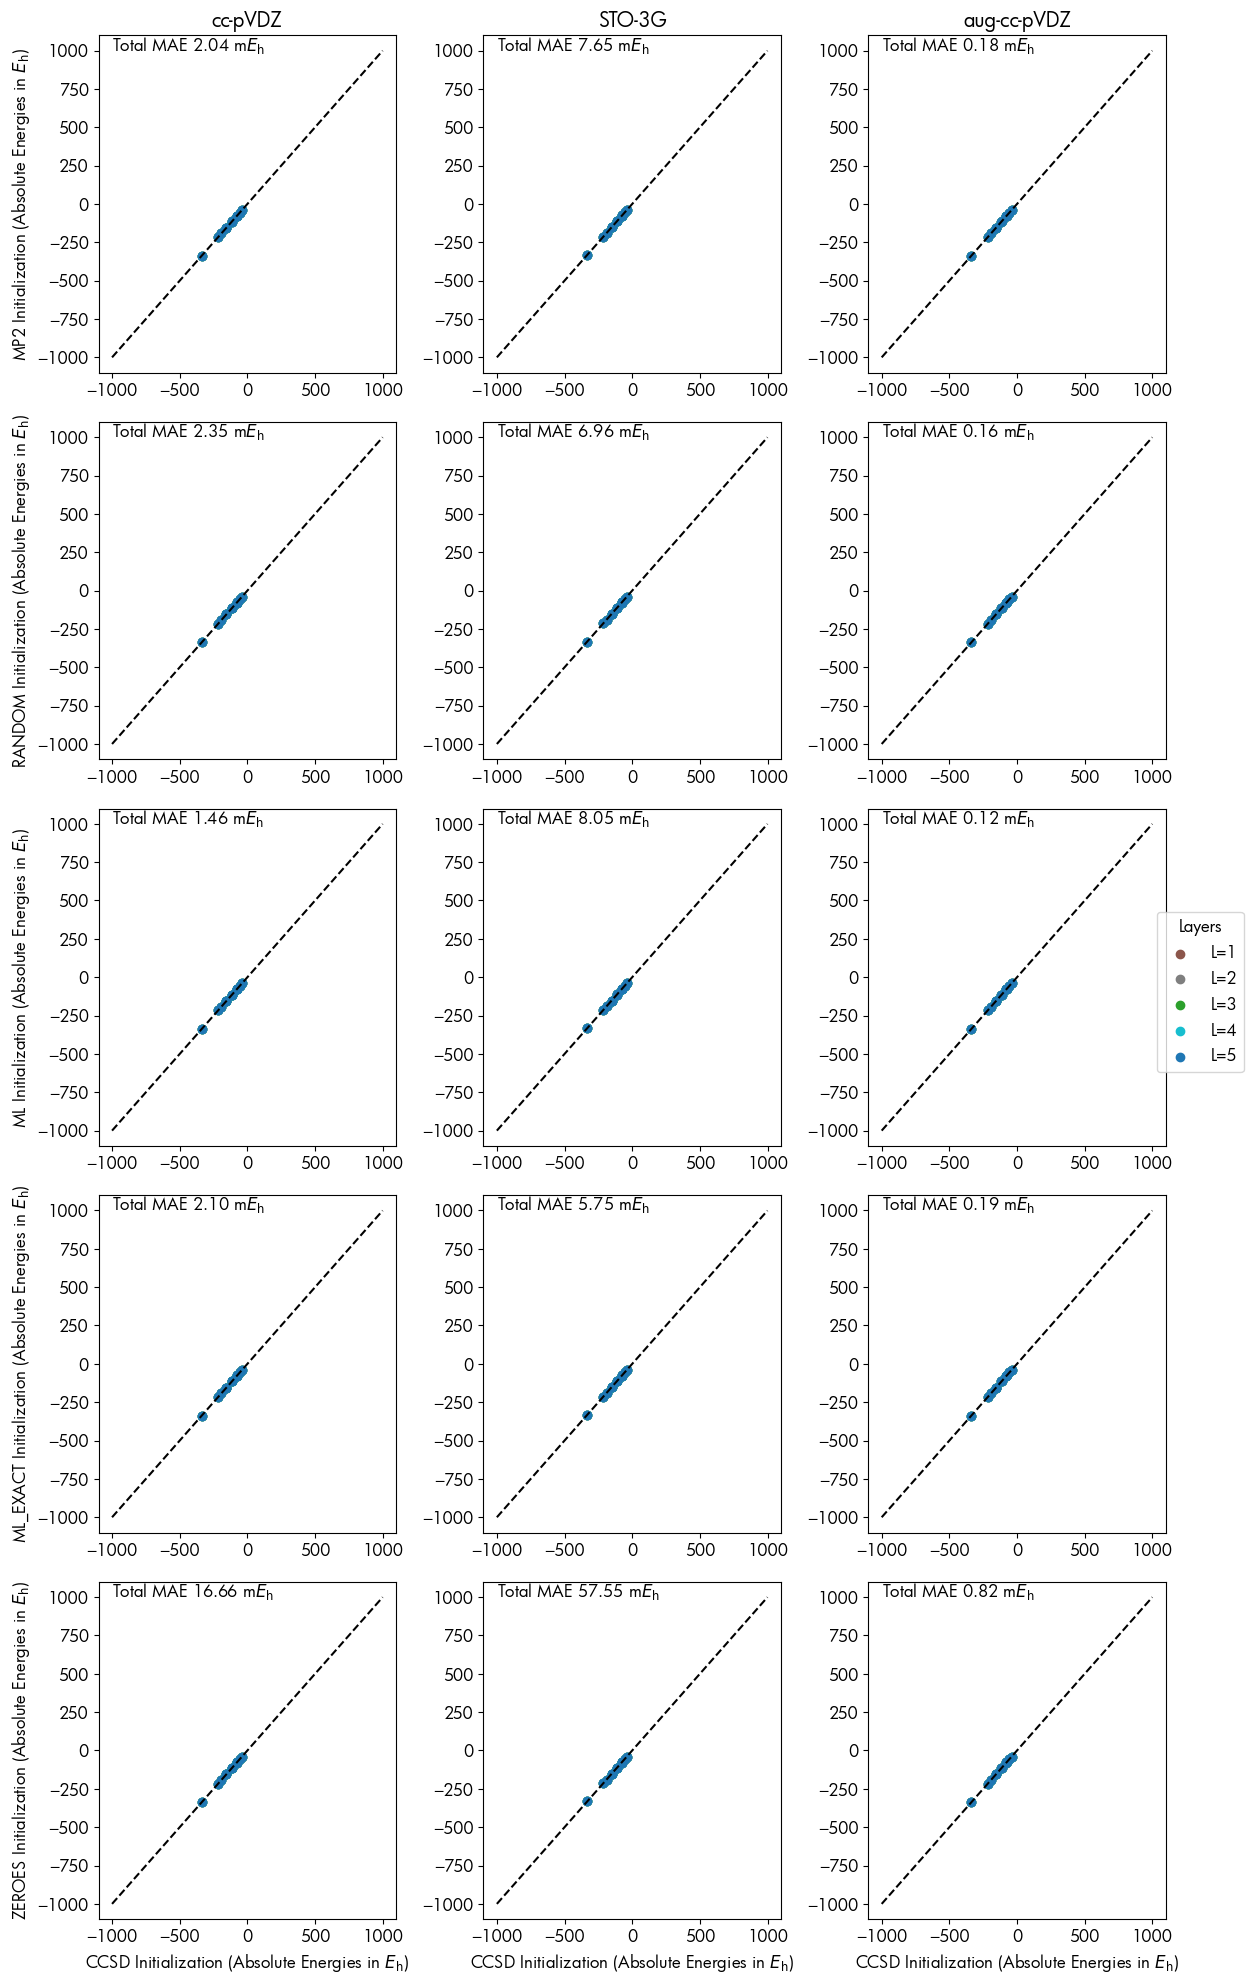

In [45]:
methods = uniqueInj[uniqueInj != 'CCSD']
n_rows = len(methods)
n_cols = len(uniqueBasis)
colors = plt.cm.tab10(np.linspace(0, 1, len(uniqueLayers)))
layer_color = dict(zip(uniqueLayers, colors))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

stats = []
added_labels = set()  # Fix #2: track labels to avoid duplicates

for (i, method), (j, basis) in product(enumerate(methods), enumerate(uniqueBasis)):
    ax = axes[i, j]
    all_ref, all_vals = [], []  # Fix #1: collect all data for axis limits
    # Loop layers
    for layers in sorted(uniqueLayers):
        ref_list, vals_list = [], []

        for mol in uniqueMol:
            mask = (
                (LUCJDF['Basis Set'] == basis) &
                (LUCJDF['L'] == layers) &
                (LUCJDF['Molecule'] == mol)
            )
            ref = LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].values
            vals = LUCJDF.loc[(LUCJDF['Injected'] == method) & mask, 'Energy'].values

            if len(ref) == 0 or len(vals) == 0 or len(ref) != len(vals):  # Fix #3
                continue

            ref_list.extend(ref)
            vals_list.extend(vals)

        if not ref_list:
            continue

        ref_arr = np.array(ref_list)
        vals_arr = np.array(vals_list)
        all_ref.extend(ref_arr)
        all_vals.extend(vals_arr)

        label = f'L={layers}'
        ax.scatter(
            ref_arr, vals_arr,
            color=layer_color[layers],
            label=label if label not in added_labels else None,  # Fix #2
        )
        added_labels.add(label)
        stats.append((method, basis,layers, mean_absolute_error(ref_arr, vals_arr)*1e3))
    ax.text(-1000,1000,f"Total MAE {mean_absolute_error(all_vals,all_ref)*1e3:.2f}"+r" m$E_{\mathrm{h}}$")
    ax.plot(range(-1000, 1000), range(-1000, 1000), 'k--')

    # if all_ref:  # Fix #1: use aggregated data for limits
    #     ax.set_xlim(np.floor(min(all_ref)), np.ceil(max(all_ref)))
    #     ax.set_ylim(np.floor(min(all_ref)), np.ceil(max(all_ref)))

    if i == 0: ax.set_title(basis)
    if j == 0: ax.set_ylabel(method.upper()+r" Initialization (Absolute Energies in $E_{\mathrm{h}}$)")
    if i == n_rows - 1: ax.set_xlabel(r'CCSD Initialization (Absolute Energies in $E_{\mathrm{h}}$)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='Layers', loc='center right', bbox_to_anchor=(1.05, 0.5))
plt.tight_layout() 
plt.savefig("GMJ_figures/parity_plots.png",dpi=300,bbox_inches='tight')

/tmp/ipykernel_20688/249686750.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)


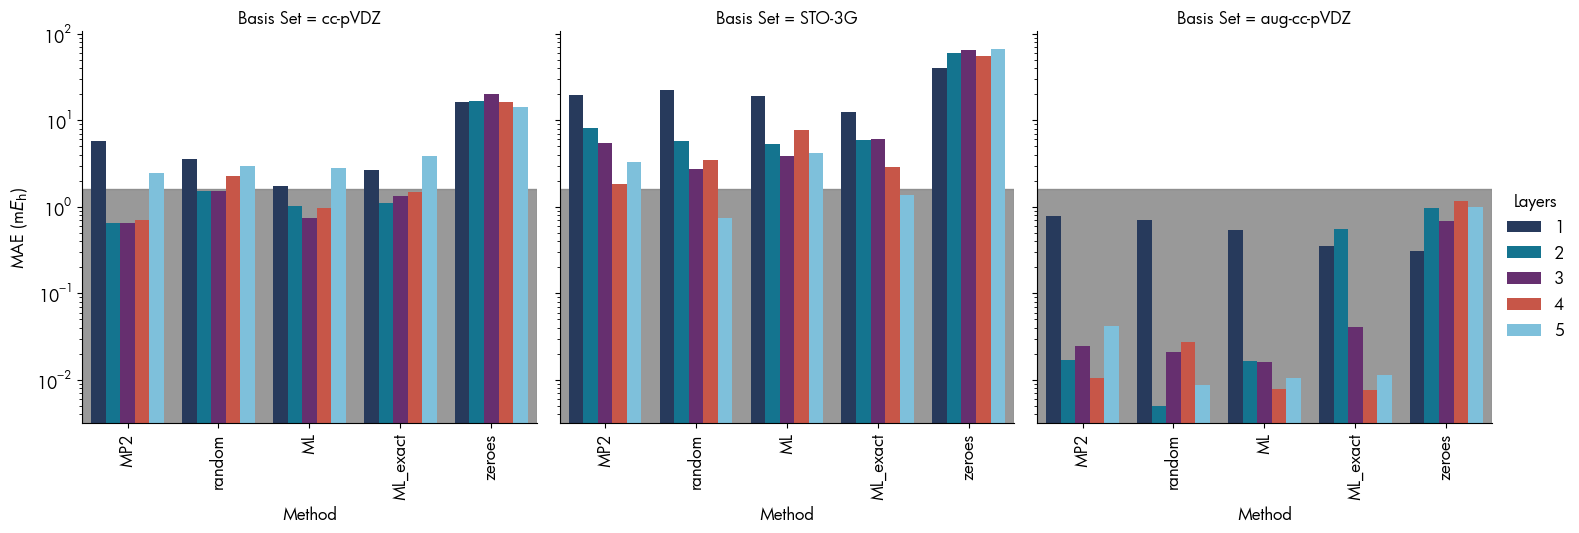

In [46]:
g = sns.catplot(pd.DataFrame(stats,columns=['Method','Basis Set','Layers','MAE']),x='Method',y='MAE',hue='Layers',col='Basis Set',kind='bar',palette=palette)
# g = sns.catplot(data=inj_mae_df,x='Molecule',y='MAE',hue='Basis',col='Injected',kind='bar',col_order=['zeroes','random','MP2','ML','ML_exact','CCSD'],palette=palette,col_wrap=3)
for ax in g.axes.flat:
    ax.set_yscale("log")
    # ax.set_ylim(ymin - pad, ymax + pad)
    ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.8)
    ax.set_ylabel(r"MAE (m$E_{\mathrm{h}}$)")
    # # Gray fill region across same y-span
    # ax.fill_between(
    #     np.linspace(-0.5, len(LUCJDF["Method"].unique()) - 0.5, 100),
    #     -1.6, 1.6,
    #     color="gray", alpha=0.2
    # )
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)
    # ax.set_xlim(-0.5, len(LUCJDF["Method"].unique()) - 0.5)

    # Rotate and align x tick labels
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")

In [47]:
stats

[('MP2', 'cc-pVDZ', np.int64(1), 5.717610000001372),
 ('MP2', 'cc-pVDZ', np.int64(2), 0.6497633333270395),
 ('MP2', 'cc-pVDZ', np.int64(3), 0.6527233333362877),
 ('MP2', 'cc-pVDZ', np.int64(4), 0.6957358333382994),
 ('MP2', 'cc-pVDZ', np.int64(5), 2.4709491666676797),
 ('MP2', 'STO-3G', np.int64(1), 19.440824166667998),
 ('MP2', 'STO-3G', np.int64(2), 8.165667499997179),
 ('MP2', 'STO-3G', np.int64(3), 5.5109058333400185),
 ('MP2', 'STO-3G', np.int64(4), 1.8304191666729253),
 ('MP2', 'STO-3G', np.int64(5), 3.3253374999991556),
 ('MP2', 'aug-cc-pVDZ', np.int64(1), 0.7908733333342374),
 ('MP2', 'aug-cc-pVDZ', np.int64(2), 0.017212500006043758),
 ('MP2', 'aug-cc-pVDZ', np.int64(3), 0.024413333331807507),
 ('MP2', 'aug-cc-pVDZ', np.int64(4), 0.010395000005066398),
 ('MP2', 'aug-cc-pVDZ', np.int64(5), 0.041629166661986496),
 ('random', 'cc-pVDZ', np.int64(1), 3.531282499999714),
 ('random', 'cc-pVDZ', np.int64(2), 1.5309658333357845),
 ('random', 'cc-pVDZ', np.int64(3), 1.5074200000017395),

In [48]:
stat_df = pd.DataFrame(stats,columns=['Method','Basis','Layers','MAE'])
stat_df['Ref'] = 'CCSD'

In [49]:
stat_df

,Method,Basis,Layers,MAE,Ref
0,MP2,cc-pVDZ,1,5.717610,CCSD
1,MP2,cc-pVDZ,2,0.649763,CCSD
2,MP2,cc-pVDZ,3,0.652723,CCSD
3,MP2,cc-pVDZ,4,0.695736,CCSD
4,MP2,cc-pVDZ,5,2.470949,CCSD
...,...,...,...,...,...
70,zeroes,aug-cc-pVDZ,1,0.307947,CCSD
71,zeroes,aug-cc-pVDZ,2,0.959261,CCSD
72,zeroes,aug-cc-pVDZ,3,0.685780,CCSD
73,zeroes,aug-cc-pVDZ,4,1.169099,CCSD


In [50]:
LUCJDF.loc[LUCJDF.loc[(LUCJDF['Injected'] == 'CCSD') & mask, 'Energy'].index]

,Basis Set,Molecule,Method,L,Injected,Energy,n_atoms,Deviation,Energy (HCI),Energy (HF),Energy (CASCI),Energy (DMRG-CASCI)
961,aug-cc-pVDZ,ammonia,LUCJ(L=5),5,CCSD,-56.205309,4,0.0,-56.205307,-56.205223,-56.205309,-55.903941


<Axes: xlabel='Deviation', ylabel='Density'>

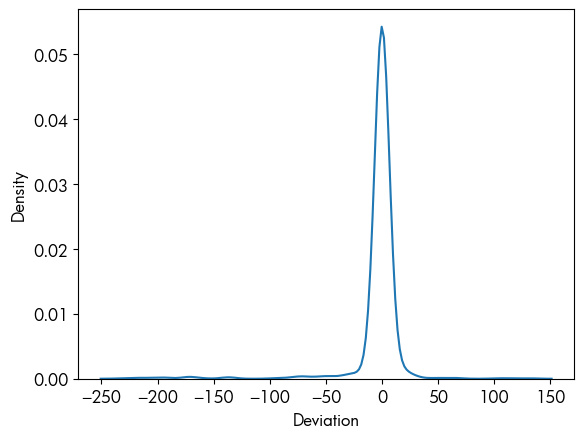

In [51]:
sns.kdeplot(LUCJDF['Deviation'])

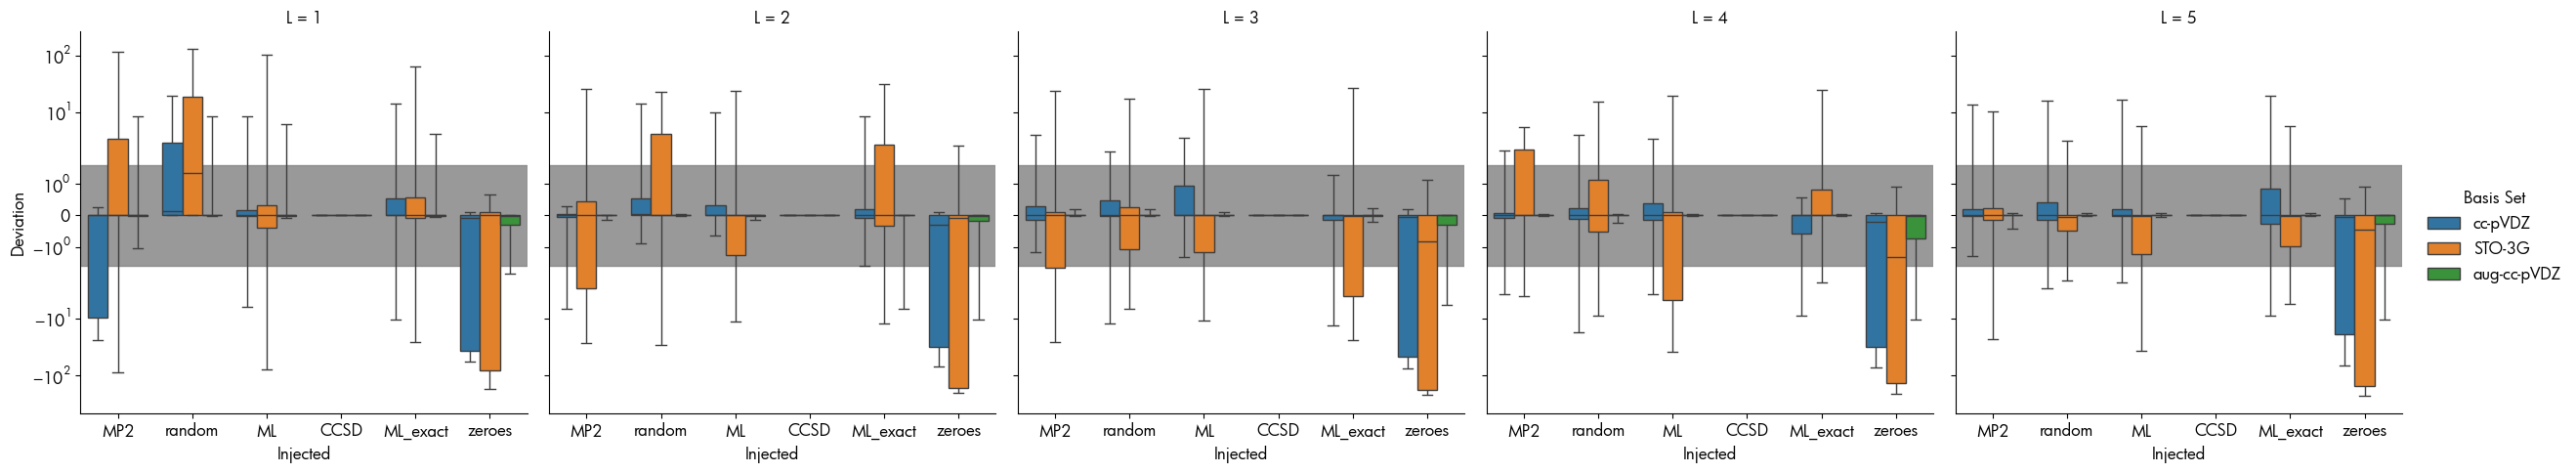

In [52]:
g = sns.catplot(data=LUCJDF, y='Deviation', x='Injected', hue='Basis Set', col='L', kind='box',
                whis=(0, 100))  # or whis=np.inf

for ax in g.axes.flat:
    ax.set_yscale('symlog')
    ax.axhspan(-1.6, 1.6, color='gray', alpha=0.8, zorder=0)

In [53]:
sns.color_palette("colorblind").as_hex()

['#0173b2',
 '#de8f05',
 '#029e73',
 '#d55e00',
 '#cc78bc',
 '#ca9161',
 '#fbafe4',
 '#949494',
 '#ece133',
 '#56b4e9']

In [54]:
for i in sns.color_palette("colorblind").as_hex():
    print(i)

#0173b2
#de8f05
#029e73
#d55e00
#cc78bc
#ca9161
#fbafe4
#949494
#ece133
#56b4e9


In [55]:
LUCJDF['Deviation'].describe()

count    1080.000000
mean       -3.644849
std        26.282190
min      -231.160190
25%        -0.004525
50%         0.000000
75%         0.002380
max       131.539180
Name: Deviation, dtype: float64

# Stack all data

In [56]:
energyDF

,Method,Energy,Name,Basis Set
0,HF,-74.960552,water,STO-3G
1,CASCI,-75.009479,water,STO-3G
2,SCI,-75.009478,water,STO-3G
0,HF,-55.454318,ammonia,STO-3G
1,CASCI,-55.519929,ammonia,STO-3G
...,...,...,...,...
31,DMRG-CASCI,-192.001410,prop-2-en-1-ol,cc-pVDZ
32,DMRG-CASCI,-189.749396,prop-2-en-1-ol,STO-3G
33,DMRG-CASCI,-215.950558,(Z)-1-fluoroprop-1-ene,aug-cc-pVDZ
34,DMRG-CASCI,-216.001106,(Z)-1-fluoroprop-1-ene,cc-pVDZ


In [57]:
for a,b in moldf[['molecule','mol_filename']].values:
    if 'GDB' in b:
        name = b.replace('.xyz','')
        energyDF['Name'] = energyDF['Name'].replace(name,a)

In [58]:
energyDF['L'] = len(energyDF)*[np.nan]
energyDF['Injected'] = len(energyDF)*[np.nan]

In [59]:
energyDF

,Method,Energy,Name,Basis Set,L,Injected
0,HF,-74.960552,water,STO-3G,NaN,NaN
1,CASCI,-75.009479,water,STO-3G,NaN,NaN
2,SCI,-75.009478,water,STO-3G,NaN,NaN
0,HF,-55.454318,ammonia,STO-3G,NaN,NaN
1,CASCI,-55.519929,ammonia,STO-3G,NaN,NaN
...,...,...,...,...,...,...
31,DMRG-CASCI,-192.001410,prop-2-en-1-ol,cc-pVDZ,NaN,NaN
32,DMRG-CASCI,-189.749396,prop-2-en-1-ol,STO-3G,NaN,NaN
33,DMRG-CASCI,-215.950558,(Z)-1-fluoroprop-1-ene,aug-cc-pVDZ,NaN,NaN
34,DMRG-CASCI,-216.001106,(Z)-1-fluoroprop-1-ene,cc-pVDZ,NaN,NaN


In [60]:
upDF = pd.concat([energyDF,LUCJDF]).reset_index().drop(columns=['index'])
upDF['Deviation'] = np.nan

In [61]:
moldf

,molecule,formula,mol_filename,num_orbitals,n_electrons
0,ammonia,NH3,ammonia157.xyz,8,10
1,methane,CH4,methane50.xyz,9,10
2,ethylene,C2H4,ethylene42.xyz,14,16
3,ethane,C2H6,ethane28.xyz,16,18
4,water,H2O,water183.xyz,7,10
5,formaldehyde,CH20,formaldehyde138.xyz,12,16
6,methanol,CH3OH,methanol22.xyz,14,18
7,fluoroform,CHF3,GDB04_5.xyz,21,34
8,"buta-1,3-diene",C4H6,GDB04_53.xyz,26,30
9,but-1-yne,C4H6,GDB04_49.xyz,26,30
